# Motor Imagery Decoder — Train OFFLINE, Evaluate ONLINE (FES vs NOFES)

For each subject × offline-session, train a CSP + LDA classifier on the OFFLINE recording, then apply it to the two matched ONLINE sessions.

**Pair 1:** train on `S001 OFFLINE_FES` → test on `S002 ONLINE_FES` and `S003 ONLINE_NOFES`
**Pair 2:** train on `S004 OFFLINE_NOFES` → test on `S006 ONLINE_FES` and `S005 ONLINE_NOFES`

**Metrics reported per (subject × pair × condition):**
1. **Classification accuracy** — fraction of cued trials correctly classified
2. **Classification amplitude** — mean |LDA decision-function value|
3. **SNR** — (a) Fisher ratio of the LDA projection on online data, and (b) mu-band power ratio REST / MI over motor channels C3/Cz/C4

In [2]:
# Install dependencies if needed
# !pip install pyxdf mne scipy numpy matplotlib

In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pyxdf
from scipy.signal import welch, butter, filtfilt, iirnotch
from scipy.linalg import eigh
from scipy.stats import wasserstein_distance

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## Configuration

In [2]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Group 2 - Glove')

# Marker codes (from experiment trigger table)
MI_BEGIN       = 200
MI_END         = 220
MI_EARLYSTOP   = 240   # online only: live classifier fired → successful MI detection
REST_BEGIN     = 100
REST_END       = 120
REST_EARLYSTOP = 140   # online only: live classifier fired → successful REST detection
ROBOT_BEGIN    = 300
ROBOT_END      = 320

TARGET_MARKERS = [100, 120, 140, 200, 220, 240]

T_PRE  = -1.0
T_POST =  5.0

# ── Preprocessing ────────────────────────────────────────────────────────────
NOTCH_FREQ     = 60.0
NOTCH_Q        = 30
BP_LO, BP_HI   = 8.0, 30.0
USE_CAR        = True
PTP_REJECT_UV  = 100.0

N_CSP = 4

NON_EEG = {'AUX1', 'AUX2', 'AUX3', 'AUX7', 'AUX8', 'AUX9', 'TRIGGER'}
RENAME  = {'FP1':'Fp1','FPZ':'Fpz','FP2':'Fp2','FZ':'Fz','CZ':'Cz',
           'PZ':'Pz','POZ':'POz','OZ':'Oz'}

MOTOR_CH = ['C3', 'Cz', 'C4']
MU_BAND  = (8, 13)

PAIRS = [
    {'name':  'Pair1 (train=OFFLINE_FES)',
     'train': 'S001', 'online_fes': 'S002', 'online_nofes': 'S003'},
    {'name':  'Pair2 (train=OFFLINE_NOFES)',
     'train': 'S004', 'online_fes': 'S006', 'online_nofes': 'S005'},
]

## Helper Functions

In [3]:
# ── XDF loading + session parsing ─────────────────────────────────────────────

def get_channel_names_from_xdf(eeg_stream):
    ch_desc  = eeg_stream['info']['desc'][0]
    channels = ch_desc.get('channels', [{}])[0].get('channel', [])
    return [ch['label'][0] for ch in channels]


_SESSION_RE = re.compile(r'ses-(S\d+)(O[A-Z]*LINE)_(FES|NOFES)')
_SUBJ_RE    = re.compile(r'SUBJ_(\d+)')

def parse_session(path):
    base   = os.path.basename(path)
    m_subj = _SUBJ_RE.search(base)
    m_ses  = _SESSION_RE.search(base)
    if not (m_subj and m_ses):
        return None
    ses_id, raw_kind, stim = m_ses.group(1), m_ses.group(2), m_ses.group(3)
    kind = 'OFFLINE' if 'OFF' in raw_kind else 'ONLINE'
    return m_subj.group(1), ses_id, kind, stim


def load_xdf_file(filepath):
    streams, _ = pyxdf.load_xdf(filepath)

    eeg_stream = marker_stream = None
    for s in streams:
        stype = s['info']['type'][0].lower()
        if stype == 'eeg':       eeg_stream    = s
        elif stype == 'markers': marker_stream = s
    if eeg_stream is None or marker_stream is None:
        eeg_stream    = streams[0]
        marker_stream = streams[1] if len(streams) > 1 else None

    eeg_timestamps = np.array(eeg_stream['time_stamps'])
    eeg_data       = np.array(eeg_stream['time_series']).T
    channel_names  = get_channel_names_from_xdf(eeg_stream)
    sfreq          = float(eeg_stream['info']['nominal_srate'][0])

    valid_idx     = [i for i, ch in enumerate(channel_names) if ch not in NON_EEG]
    channel_names = [channel_names[i] for i in valid_idx]
    eeg_data      = eeg_data[valid_idx, :]
    channel_names = [RENAME.get(ch, ch) for ch in channel_names]

    ts_arr      = np.asarray(marker_stream['time_series'], dtype=float)
    marker_data = ts_arr[:, 0].astype(int)
    marker_ts   = ts_arr[:, 1]
    keep        = np.isin(marker_data, TARGET_MARKERS)
    return eeg_data, eeg_timestamps, marker_data[keep], marker_ts[keep], channel_names, sfreq


# ── Preprocessing primitives ─────────────────────────────────────────────────

def notch_filter(data, freq, sfreq, Q=NOTCH_Q):
    b, a = iirnotch(freq, Q, fs=sfreq)
    return filtfilt(b, a, data, axis=-1)


def car(data):
    return data - data.mean(axis=0, keepdims=True)


def bandpass(data, lo, hi, sfreq, order=4):
    nyq  = sfreq / 2.0
    b, a = butter(order, [max(lo, 0.5) / nyq, min(hi, nyq - 0.1) / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)


def reject_by_ptp(X, thresh_uv=PTP_REJECT_UV):
    if X.size == 0:
        return np.zeros(0, dtype=bool)
    ptp = X.max(axis=-1) - X.min(axis=-1)
    return ptp.max(axis=-1) < thresh_uv


def extract_epochs(eeg_data, eeg_ts, marker_data, marker_ts, sfreq, begin_code,
                   t_pre=T_PRE, t_post=T_POST):
    epochs = []
    n_pre  = int(abs(t_pre) * sfreq)
    for bi in np.where(marker_data == begin_code)[0]:
        t_start = marker_ts[bi]
        i0 = np.searchsorted(eeg_ts, t_start + t_pre)
        i1 = np.searchsorted(eeg_ts, t_start + t_post)
        if i0 < 0 or i1 > eeg_data.shape[1]:
            continue
        ep = eeg_data[:, i0:i1].copy()
        if ep.shape[1] > n_pre:
            ep -= ep[:, :n_pre].mean(axis=1, keepdims=True)
        epochs.append(ep)
    if not epochs:
        return np.empty((0, eeg_data.shape[0], 0))
    min_len = min(e.shape[-1] for e in epochs)
    return np.stack([e[:, :min_len] for e in epochs])


# ── Trial-level parsing from markers ─────────────────────────────────────────

def trial_events(marker_data, marker_ts):
    """Parse marker stream into ordered per-trial records.
    Returns list of dicts with keys: cls ('MI'|'REST'), success (bool),
    latency (seconds from BEGIN to EARLYSTOP, or None on failure), t_begin.
    """
    begin_codes = {MI_BEGIN: 'MI', REST_BEGIN: 'REST'}
    early_of    = {'MI': MI_EARLYSTOP, 'REST': REST_EARLYSTOP}

    begin_idx = np.where(np.isin(marker_data, list(begin_codes.keys())))[0]
    trials = []
    for i, bi in enumerate(begin_idx):
        cls     = begin_codes[int(marker_data[bi])]
        t_begin = float(marker_ts[bi])
        # Search until next BEGIN (or end of stream) for EARLYSTOP of matching class
        end    = begin_idx[i + 1] if i + 1 < len(begin_idx) else len(marker_data)
        window = marker_data[bi + 1:end]
        wts    = marker_ts[bi + 1:end]
        hit    = np.where(window == early_of[cls])[0]
        if len(hit):
            trials.append(dict(cls=cls, success=True,
                               latency=float(wts[hit[0]] - t_begin), t_begin=t_begin))
        else:
            trials.append(dict(cls=cls, success=False, latency=None, t_begin=t_begin))
    return trials


def marker_stats(marker_data, marker_ts):
    """Online performance summary from markers. Returns None for offline sessions.
    Fields: mk_acc, mi_acc, rest_acc, mi_latency, rest_latency, trials (ordered).
    """
    trials = trial_events(marker_data, marker_ts)
    if not trials or not any(t['success'] for t in trials):
        return None   # offline or no successful trials
    mi   = [t for t in trials if t['cls'] == 'MI']
    rest = [t for t in trials if t['cls'] == 'REST']

    def _acc(ts): return sum(t['success'] for t in ts) / len(ts) if ts else None
    def _lat(ts):
        lats = [t['latency'] for t in ts if t['success']]
        return float(np.mean(lats)) if lats else None

    n_correct = sum(t['success'] for t in trials)
    return dict(mk_acc = n_correct / len(trials),
                mi_acc = _acc(mi),  rest_acc = _acc(rest),
                mi_latency = _lat(mi), rest_latency = _lat(rest),
                trials = trials)


def load_session_epochs(filepath):
    """Preprocessing pipeline: notch → CAR → bandpass → epoch → PTP-reject.
    Returns X, y, ch_names, sfreq, n_rejected, stats
    where `stats` is the marker_stats() dict (None for offline sessions).
    """
    eeg, eeg_ts, mk, mk_ts, ch_names, sfreq = load_xdf_file(filepath)

    stats = marker_stats(mk, mk_ts)

    eeg = notch_filter(eeg, NOTCH_FREQ, sfreq)
    if USE_CAR:
        eeg = car(eeg)
    eeg_bp = bandpass(eeg, BP_LO, BP_HI, sfreq)

    mi   = extract_epochs(eeg_bp, eeg_ts, mk, mk_ts, sfreq, MI_BEGIN)
    rest = extract_epochs(eeg_bp, eeg_ts, mk, mk_ts, sfreq, REST_BEGIN)

    n_pre = int(abs(T_PRE) * sfreq)
    if mi.shape[-1]   > n_pre: mi   = mi[..., n_pre:]
    if rest.shape[-1] > n_pre: rest = rest[..., n_pre:]

    n = min(mi.shape[-1], rest.shape[-1]) if (mi.size and rest.size) else 0
    mi, rest = mi[..., :n], rest[..., :n]

    n0_mi, n0_rest = len(mi), len(rest)
    mi   = mi[reject_by_ptp(mi)]
    rest = rest[reject_by_ptp(rest)]
    n_rejected = (n0_mi - len(mi)) + (n0_rest - len(rest))

    X = np.concatenate([mi, rest], axis=0) if (len(mi) or len(rest)) else np.empty((0, len(ch_names), 0))
    y = np.concatenate([np.ones(len(mi), int), np.zeros(len(rest), int)])
    return X, y, ch_names, sfreq, n_rejected, stats


# ── CSP + LDA (2-class, numpy/scipy only) ────────────────────────────────────

def _mean_cov(X):
    covs = np.einsum('ijk,ilk->ijl', X, X)
    covs /= np.trace(covs, axis1=1, axis2=2)[:, None, None]
    return covs.mean(axis=0)


class CSPLDA:
    """CSP log-var features + LDA. Ramoser 2000; Blankertz 2008.
    Ledoit-Wolf shrinkage keeps the generalized eigenproblem well-posed after CAR.
    """

    def __init__(self, n_csp=N_CSP, cov_shrink=0.05, lda_reg=1e-4):
        self.n_csp      = n_csp
        self.cov_shrink = cov_shrink
        self.lda_reg    = lda_reg

    def fit(self, X, y):
        assert set(np.unique(y)) == {0, 1}
        C1 = _mean_cov(X[y == 1])
        C0 = _mean_cov(X[y == 0])
        n_ch = C1.shape[0]
        s = self.cov_shrink
        C1 = (1 - s) * C1 + s * (np.trace(C1) / n_ch) * np.eye(n_ch)
        C0 = (1 - s) * C0 + s * (np.trace(C0) / n_ch) * np.eye(n_ch)
        evals, evecs = eigh(C1, C0 + C1)
        order  = np.argsort(evals)
        k      = self.n_csp // 2
        self.filters_ = np.concatenate([evecs[:, order[:k]],
                                        evecs[:, order[-k:]]], axis=1).T
        F = self._features(X)
        mu1, mu0 = F[y == 1].mean(0), F[y == 0].mean(0)
        Sw = np.cov(F[y == 1].T, ddof=1) + np.cov(F[y == 0].T, ddof=1)
        Sw += self.lda_reg * np.eye(Sw.shape[0])
        self.coef_      = np.linalg.solve(Sw, mu1 - mu0)
        self.intercept_ = -self.coef_ @ ((mu1 + mu0) / 2)
        return self

    def _features(self, X):
        Z   = np.einsum('fc,ncs->nfs', self.filters_, X)
        var = Z.var(axis=-1, ddof=1)
        return np.log(var / var.sum(axis=1, keepdims=True))

    def decision_function(self, X):
        return self._features(X) @ self.coef_ + self.intercept_

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)


# ── Evaluation metrics ───────────────────────────────────────────────────────

def evaluate(clf, X, y):
    margin = clf.decision_function(X)
    pred   = (margin > 0).astype(int)
    amp    = np.abs(margin).mean()
    m1, m0 = margin[y == 1], margin[y == 0]
    fisher = (m1.mean() - m0.mean()) ** 2 / (m1.var(ddof=1) + m0.var(ddof=1) + 1e-30)
    return dict(amp=amp, fisher=fisher, margin=margin, y=y, pred=pred)


def spectral_snr(X, y, ch_idx, sfreq, band=MU_BAND):
    def band_pwr(sig):
        f, p = welch(sig, fs=sfreq,
                     nperseg=min(int(sfreq * 2), sig.shape[-1]),
                     noverlap=int(sfreq), axis=-1)
        m = (f >= band[0]) & (f < band[1])
        return np.trapezoid(p[..., m], f[m], axis=-1).mean()
    return band_pwr(X[y == 0][:, ch_idx, :]) / (band_pwr(X[y == 1][:, ch_idx, :]) + 1e-30)

## Load Data

In [4]:
xdf_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.xdf')))
print(f'Found {len(xdf_files)} XDF file(s).')
print(f'Preprocessing: notch {NOTCH_FREQ:.0f} Hz → '
      f'{"CAR → " if USE_CAR else ""}bandpass {BP_LO:.0f}–{BP_HI:.0f} Hz → '
      f'baseline-correct → PTP-reject @ {PTP_REJECT_UV:.0f} µV\n')

sessions  = {}
total_rej = 0

for fp in xdf_files:
    meta = parse_session(fp)
    if meta is None:
        print(f'  SKIP (unparsed): {os.path.basename(fp)}')
        continue
    subj, ses_id, kind, stim = meta
    try:
        X, y, ch_names, sfreq, n_rej, stats = load_session_epochs(fp)
    except Exception as e:
        print(f'  ERROR {os.path.basename(fp)}: {e}')
        continue

    sessions.setdefault(subj, {})[ses_id] = dict(
        X=X, y=y, kind=kind, stim=stim,
        ch_names=ch_names, sfreq=sfreq,
        stats=stats, file=os.path.basename(fp))
    total_rej += n_rej

    if stats is not None:
        info = (f'  acc={stats["mk_acc"]:.3f} '
                f'(MI={stats["mi_acc"]:.2f}, REST={stats["rest_acc"]:.2f})  '
                f'lat(MI={stats["mi_latency"]:.2f}s, REST={stats["rest_latency"]:.2f}s)'
                if stats['mi_acc'] is not None and stats['rest_acc'] is not None else '')
    else:
        info = ''
    print(f'  {subj}/{ses_id}  {kind:<7} {stim:<5}  '
          f'n={len(y):3d}  (MI={int(y.sum())}, REST={int((1-y).sum())})  '
          f'rej={n_rej}{info}')

subjects = sorted(sessions.keys())
print(f'\nLoaded {len(subjects)} subject(s): {subjects}  |  '
      f'total artifact-rejected epochs: {total_rej}')

Found 24 XDF file(s).
Preprocessing: notch 60 Hz → CAR → bandpass 8–30 Hz → baseline-correct → PTP-reject @ 100 µV

  002/S001  OFFLINE FES    n= 85  (MI=43, REST=42)  rej=5
  002/S002  ONLINE  FES    n= 53  (MI=27, REST=26)  rej=7  acc=0.883 (MI=0.87, REST=0.90)  lat(MI=2.74s, REST=2.46s)
  002/S003  ONLINE  NOFES  n= 52  (MI=26, REST=26)  rej=8  acc=0.833 (MI=0.87, REST=0.80)  lat(MI=2.26s, REST=2.29s)
  002/S004  OFFLINE NOFES  n= 90  (MI=45, REST=45)  rej=0
  002/S005  ONLINE  NOFES  n= 60  (MI=30, REST=30)  rej=0  acc=0.850 (MI=0.83, REST=0.87)  lat(MI=2.33s, REST=2.15s)
  002/S006  ONLINE  FES    n= 56  (MI=27, REST=29)  rej=4  acc=0.917 (MI=1.00, REST=0.83)  lat(MI=2.26s, REST=1.76s)
  003/S001  OFFLINE FES    n= 89  (MI=44, REST=45)  rej=1
  003/S002  ONLINE  FES    n= 59  (MI=29, REST=30)  rej=1  acc=0.750 (MI=0.70, REST=0.80)  lat(MI=2.59s, REST=2.12s)
  003/S003  ONLINE  NOFES  n= 38  (MI=17, REST=21)  rej=0  acc=0.763 (MI=0.76, REST=0.76)  lat(MI=2.15s, REST=2.74s)
  003/S0

## Verify Session Layout

In [5]:
# Verify channel layout is consistent across sessions, locate motor channels
ref_subj = subjects[0]
ref_ses  = next(iter(sessions[ref_subj].values()))
channel_names_global = ref_ses['ch_names']
sfreq_global         = ref_ses['sfreq']

mismatches = [f'{subj}/{sid}' for subj in subjects for sid, s in sessions[subj].items()
              if s['ch_names'] != channel_names_global]
if mismatches:
    print('!! channel mismatch in:', mismatches)

motor_idx_global = [channel_names_global.index(c) for c in MOTOR_CH
                    if c in channel_names_global]

print(f'Channels ({len(channel_names_global)}): {channel_names_global}')
print(f'Sampling rate: {sfreq_global} Hz')
print(f'Motor channels {MOTOR_CH} → indices {motor_idx_global}')

Channels (32): ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']
Sampling rate: 512.0 Hz
Motor channels ['C3', 'Cz', 'C4'] → indices [14, 15, 16]


## Train CSP + LDA on OFFLINE, Evaluate on ONLINE

In [6]:
MIN_TEST_TRIALS = 10

results = []

for subj in subjects:
    subj_ses = sessions[subj]

    for pair in PAIRS:
        needed  = (pair['train'], pair['online_fes'], pair['online_nofes'])
        missing = [k for k in needed if k not in subj_ses]
        if missing:
            print(f'[{subj}] {pair["name"]}: missing {missing} — skipping')
            continue

        train = subj_ses[pair['train']]
        if set(np.unique(train['y'])) != {0, 1}:
            print(f'[{subj}] {pair["name"]}: training set lacks both classes — skipping')
            continue

        clf       = CSPLDA(n_csp=N_CSP).fit(train['X'], train['y'])
        train_acc = (clf.predict(train['X']) == train['y']).mean()

        for cond_key, cond_label in [('online_fes', 'FES'), ('online_nofes', 'NOFES')]:
            te = subj_ses[pair[cond_key]]
            st = te['stats']
            if st is None:
                print(f'[{subj}] {pair["name"]} / {cond_label}: no EARLYSTOP markers — skipping')
                continue

            row = dict(
                subject=subj, pair=pair['name'], condition=cond_label,
                train_file=train['file'], test_file=te['file'],
                train_acc=train_acc, n_test=len(te['y']),
                acc          = st['mk_acc'],
                mi_acc       = st['mi_acc'],
                rest_acc     = st['rest_acc'],
                mi_latency   = st['mi_latency'],
                rest_latency = st['rest_latency'],
                trials       = st['trials'],   # ordered per-trial records for trajectory analysis
            )

            # EEG-based metrics require enough clean epochs of both classes
            if len(te['y']) >= MIN_TEST_TRIALS and set(np.unique(te['y'])) == {0, 1}:
                res   = evaluate(clf, te['X'], te['y'])
                snr_s = spectral_snr(te['X'], te['y'], motor_idx_global, te['sfreq'])
                row.update(amp=res['amp'], fisher=res['fisher'], mu_snr=snr_s,
                           margin=res['margin'], y_test=res['y'], pred=res['pred'])
            else:
                print(f'[{subj}] {pair["name"]} / {cond_label}: only {len(te["y"])} clean epochs — '
                      f'acc={st["mk_acc"]:.3f}, skipping EEG-derived metrics')
                row.update(amp=np.nan, fisher=np.nan, mu_snr=np.nan,
                           margin=np.array([]), y_test=np.array([]), pred=np.array([]))

            results.append(row)

hdr = (f'{"Subj":<5} {"Pair":<28} {"Cond":<6} {"n":>4} '
       f'{"trainAcc":>9} {"mkAcc":>7} {"MIacc":>6} {"REacc":>6} '
       f'{"MIlat":>6} {"RElat":>6} {"|marg|":>8} {"Fisher":>8} {"muSNR":>7}')
print('\n' + hdr)
print('-' * len(hdr))
for r in results:
    fmt = lambda v, s: (f'{v:{s}}' if (v is not None and not (isinstance(v, float) and np.isnan(v))) else f'{"--":>{int(s.split(".")[0].lstrip(">"))}}')
    print(f'{r["subject"]:<5} {r["pair"]:<28} {r["condition"]:<6} {r["n_test"]:>4} '
          f'{r["train_acc"]:>9.3f} {r["acc"]:>7.3f} '
          f'{r["mi_acc"]:>6.2f} {r["rest_acc"]:>6.2f} '
          f'{r["mi_latency"]:>6.2f} {r["rest_latency"]:>6.2f} '
          f'{fmt(r["amp"], ">8.3f")} {fmt(r["fisher"], ">8.3f")} {fmt(r["mu_snr"], ">7.3f")}')

[009] Pair1 (train=OFFLINE_FES) / NOFES: only 1 clean epochs — acc=0.717, skipping EEG-derived metrics

Subj  Pair                         Cond      n  trainAcc   mkAcc  MIacc  REacc  MIlat  RElat   |marg|   Fisher   muSNR
----------------------------------------------------------------------------------------------------------------------
002   Pair1 (train=OFFLINE_FES)    FES      53     0.659   0.883   0.87   0.90   2.74   2.46    0.778    0.288   1.197
002   Pair1 (train=OFFLINE_FES)    NOFES    52     0.659   0.833   0.87   0.80   2.26   2.29    1.162    0.073   1.452
002   Pair2 (train=OFFLINE_NOFES)  FES      56     0.811   0.917   1.00   0.83   2.26   1.76    1.012    3.133   1.665
002   Pair2 (train=OFFLINE_NOFES)  NOFES    60     0.811   0.850   0.83   0.87   2.33   2.15    0.756    0.695   1.576
003   Pair1 (train=OFFLINE_FES)    FES      59     0.843   0.750   0.70   0.80   2.59   2.12    0.879    0.017   1.347
003   Pair1 (train=OFFLINE_FES)    NOFES    38     0.843   0.76

---
## Figure 1 — Per-metric comparison (FES vs NOFES)

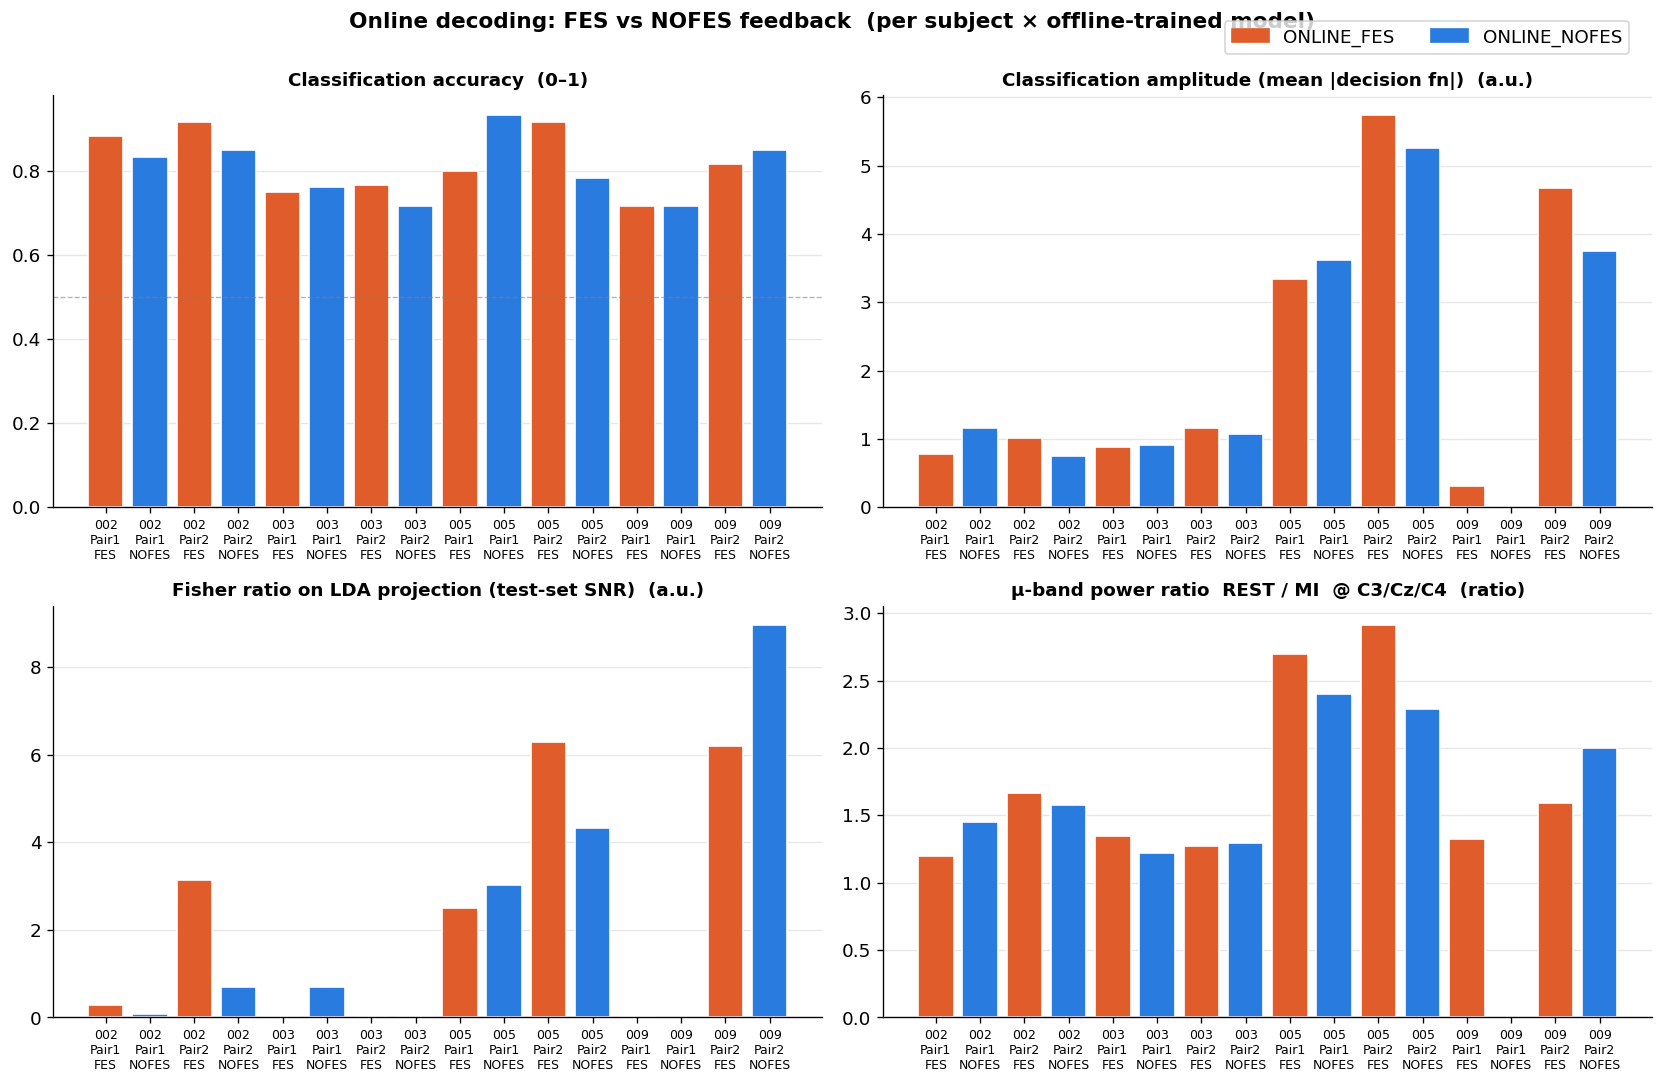

Saved: fes_vs_nofes_metrics.png


In [7]:
METRICS = [
    ('acc',    'Classification accuracy',                            '0–1'),
    ('amp',    'Classification amplitude (mean |decision fn|)',      'a.u.'),
    ('fisher', 'Fisher ratio on LDA projection (test-set SNR)',      'a.u.'),
    ('mu_snr', 'μ-band power ratio  REST / MI  @ C3/Cz/C4',          'ratio'),
]

cond_color = {'FES': '#E05C2A', 'NOFES': '#2A7BE0'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Online decoding: FES vs NOFES feedback  (per subject × offline-trained model)',
             fontsize=13, fontweight='bold', y=1.00)

for ax, (key, title, unit) in zip(axes.ravel(), METRICS):
    labels, vals, colors = [], [], []
    for subj in subjects:
        for pair in PAIRS:
            tag = pair['name'].split()[0]   # "Pair1" / "Pair2"
            for cond in ('FES', 'NOFES'):
                row = next((r for r in results
                            if r['subject']==subj and r['pair']==pair['name']
                            and r['condition']==cond), None)
                if row is None: continue
                labels.append(f'{subj}\n{tag}\n{cond}')
                vals.append(row[key])
                colors.append(cond_color[cond])
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colors, edgecolor='white', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_title(f'{title}  ({unit})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    if key == 'acc':
        ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.6)

fig.legend(handles=[Patch(color=cond_color['FES'],   label='ONLINE_FES'),
                    Patch(color=cond_color['NOFES'], label='ONLINE_NOFES')],
           loc='upper right', ncol=2, bbox_to_anchor=(0.98, 1.0))
plt.tight_layout()
plt.savefig('fes_vs_nofes_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fes_vs_nofes_metrics.png')

---
## Figure 2 — LDA decision-function distributions

Visualizes classification amplitude and separability directly: wider FES vs NOFES spread between MI and REST curves = higher Fisher ratio and larger mean |margin|.

/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


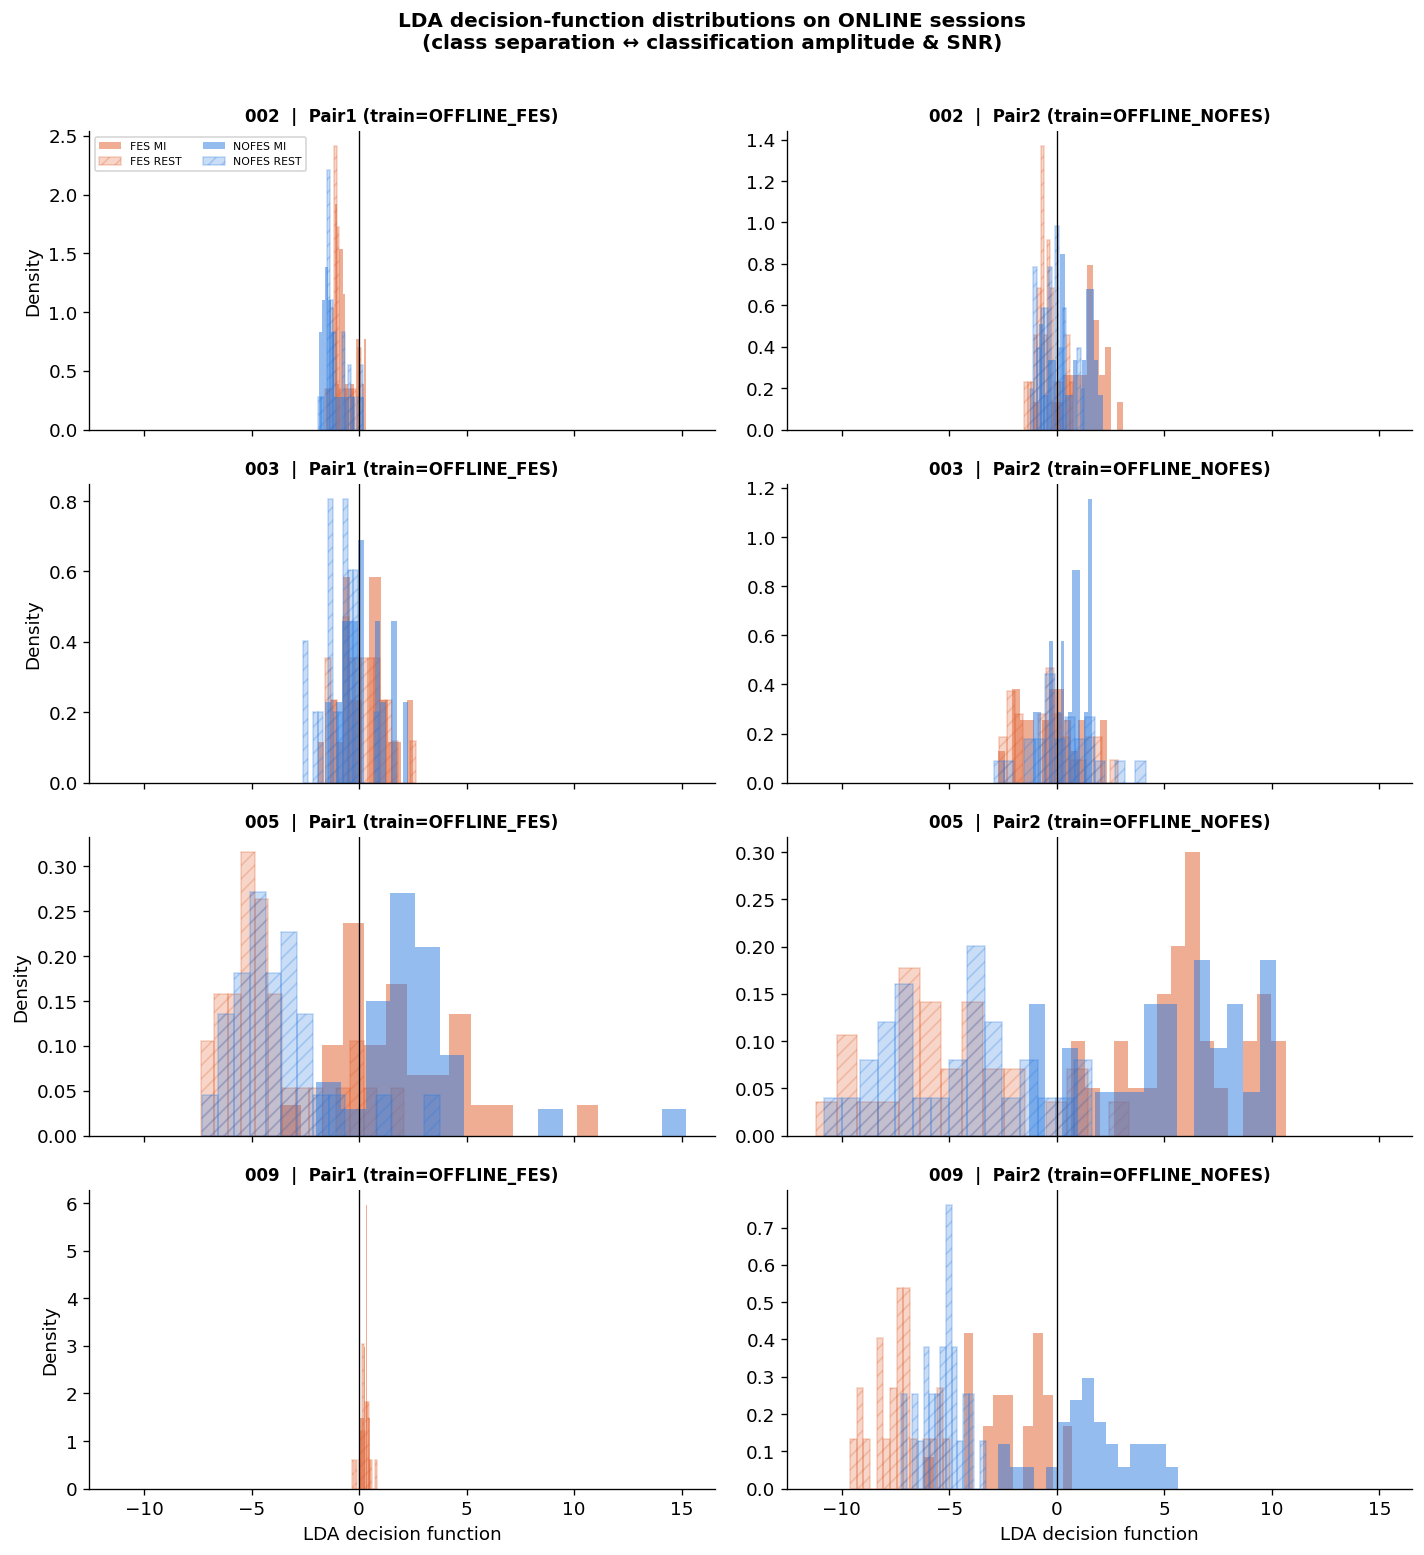

Saved: decision_margin_distributions.png


In [8]:
fig, axes = plt.subplots(len(subjects), len(PAIRS),
                         figsize=(6 * len(PAIRS), 3.2 * len(subjects)),
                         sharex=True, squeeze=False)
fig.suptitle('LDA decision-function distributions on ONLINE sessions\n'
             '(class separation ↔ classification amplitude & SNR)',
             fontsize=12, fontweight='bold', y=1.01)

for i, subj in enumerate(subjects):
    for j, pair in enumerate(PAIRS):
        ax = axes[i][j]
        for cond, color in cond_color.items():
            row = next((r for r in results
                        if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']==cond), None)
            if row is None: continue
            m_mi   = row['margin'][row['y_test'] == 1]
            m_rest = row['margin'][row['y_test'] == 0]
            ax.hist(m_mi,   bins=15, alpha=0.5,  color=color,
                    label=f'{cond} MI',   density=True)
            ax.hist(m_rest, bins=15, alpha=0.25, color=color, hatch='///',
                    edgecolor=color, label=f'{cond} REST', density=True)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_title(f'{subj}  |  {pair["name"]}', fontsize=10, fontweight='bold')
        if j == 0:                     ax.set_ylabel('Density')
        if i == len(subjects) - 1:     ax.set_xlabel('LDA decision function')
        ax.spines[['top','right']].set_visible(False)
        if i == 0 and j == 0:
            ax.legend(fontsize=6.5, loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('decision_margin_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: decision_margin_distributions.png')

---
## Figure 3 — Paired Δ (FES − NOFES) per metric

Within each (subject × pair), FES and NOFES sessions use the same offline-trained model. Positive bars mean FES > NOFES; negative means NOFES > FES. This removes the offline-model-quality confound and isolates the effect of feedback type.

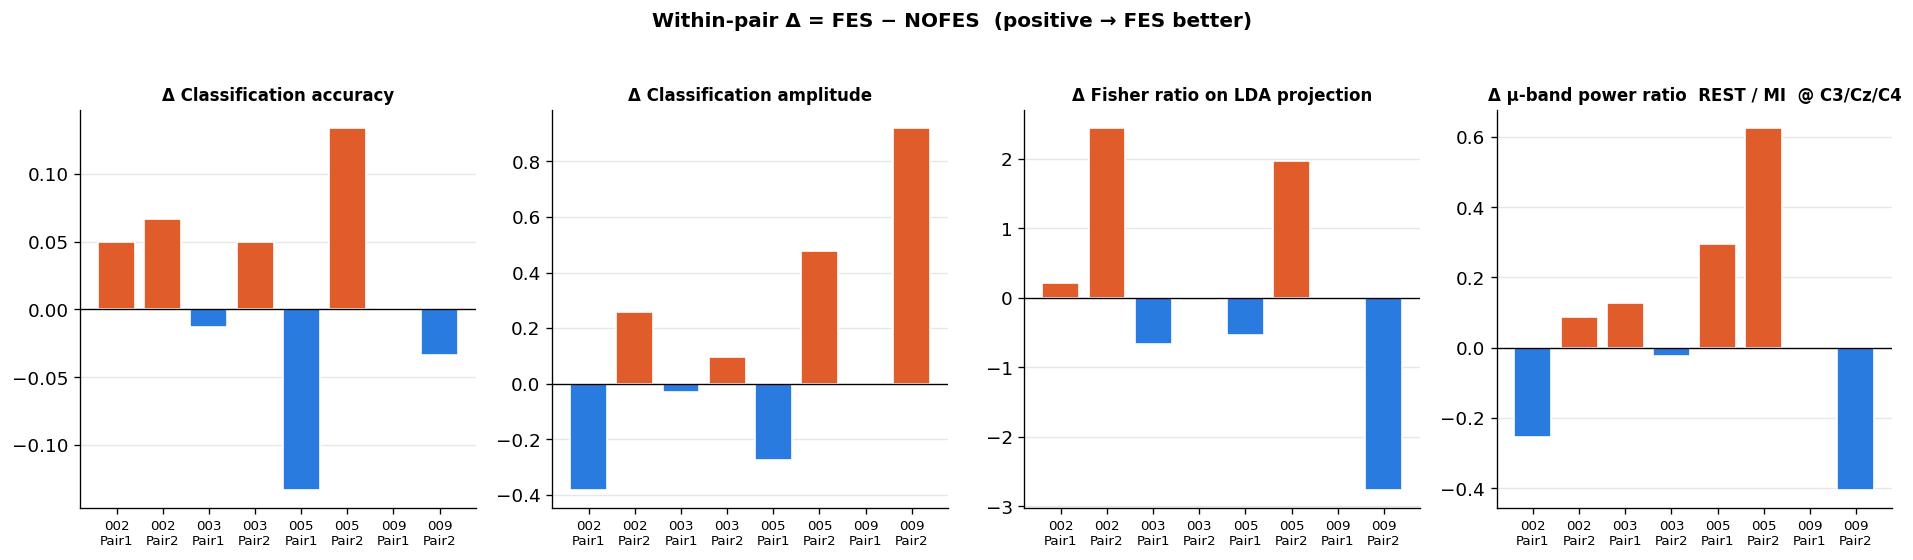

Saved: fes_minus_nofes_delta.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
fig.suptitle('Within-pair Δ = FES − NOFES  (positive → FES better)',
             fontsize=12, fontweight='bold', y=1.03)

for ax, (key, title, _) in zip(axes, METRICS):
    labels, deltas = [], []
    for subj in subjects:
        for pair in PAIRS:
            fes = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']=='FES'),   None)
            nof = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                        and r['condition']=='NOFES'), None)
            if fes is None or nof is None: continue
            deltas.append(fes[key] - nof[key])
            labels.append(f'{subj}\n{pair["name"].split()[0]}')

    colors = ['#E05C2A' if d > 0 else '#2A7BE0' for d in deltas]
    ax.bar(np.arange(len(deltas)), deltas, color=colors, edgecolor='white', zorder=2)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(np.arange(len(deltas)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'Δ {title.split("(")[0].strip()}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fes_minus_nofes_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fes_minus_nofes_delta.png')

---
## Figure 5 — Per-class accuracy and EARLYSTOP latency

FES stimulation fires only on MI trials, so if it helps the subject/system it should
show up in **MI-accuracy** (count_240 / count_200) specifically, not in REST-accuracy.
A lift in MI-acc without change in REST-acc would be a genuine sensitivity gain; an
equal-and-opposite shift would be a bias/threshold effect.

**EARLYSTOP latency** (BEGIN → EARLYSTOP in seconds) is a continuous readout of how
confidently and how fast the live classifier committed — shorter latency means a
sharper MI signal crossing the detection threshold earlier.

/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


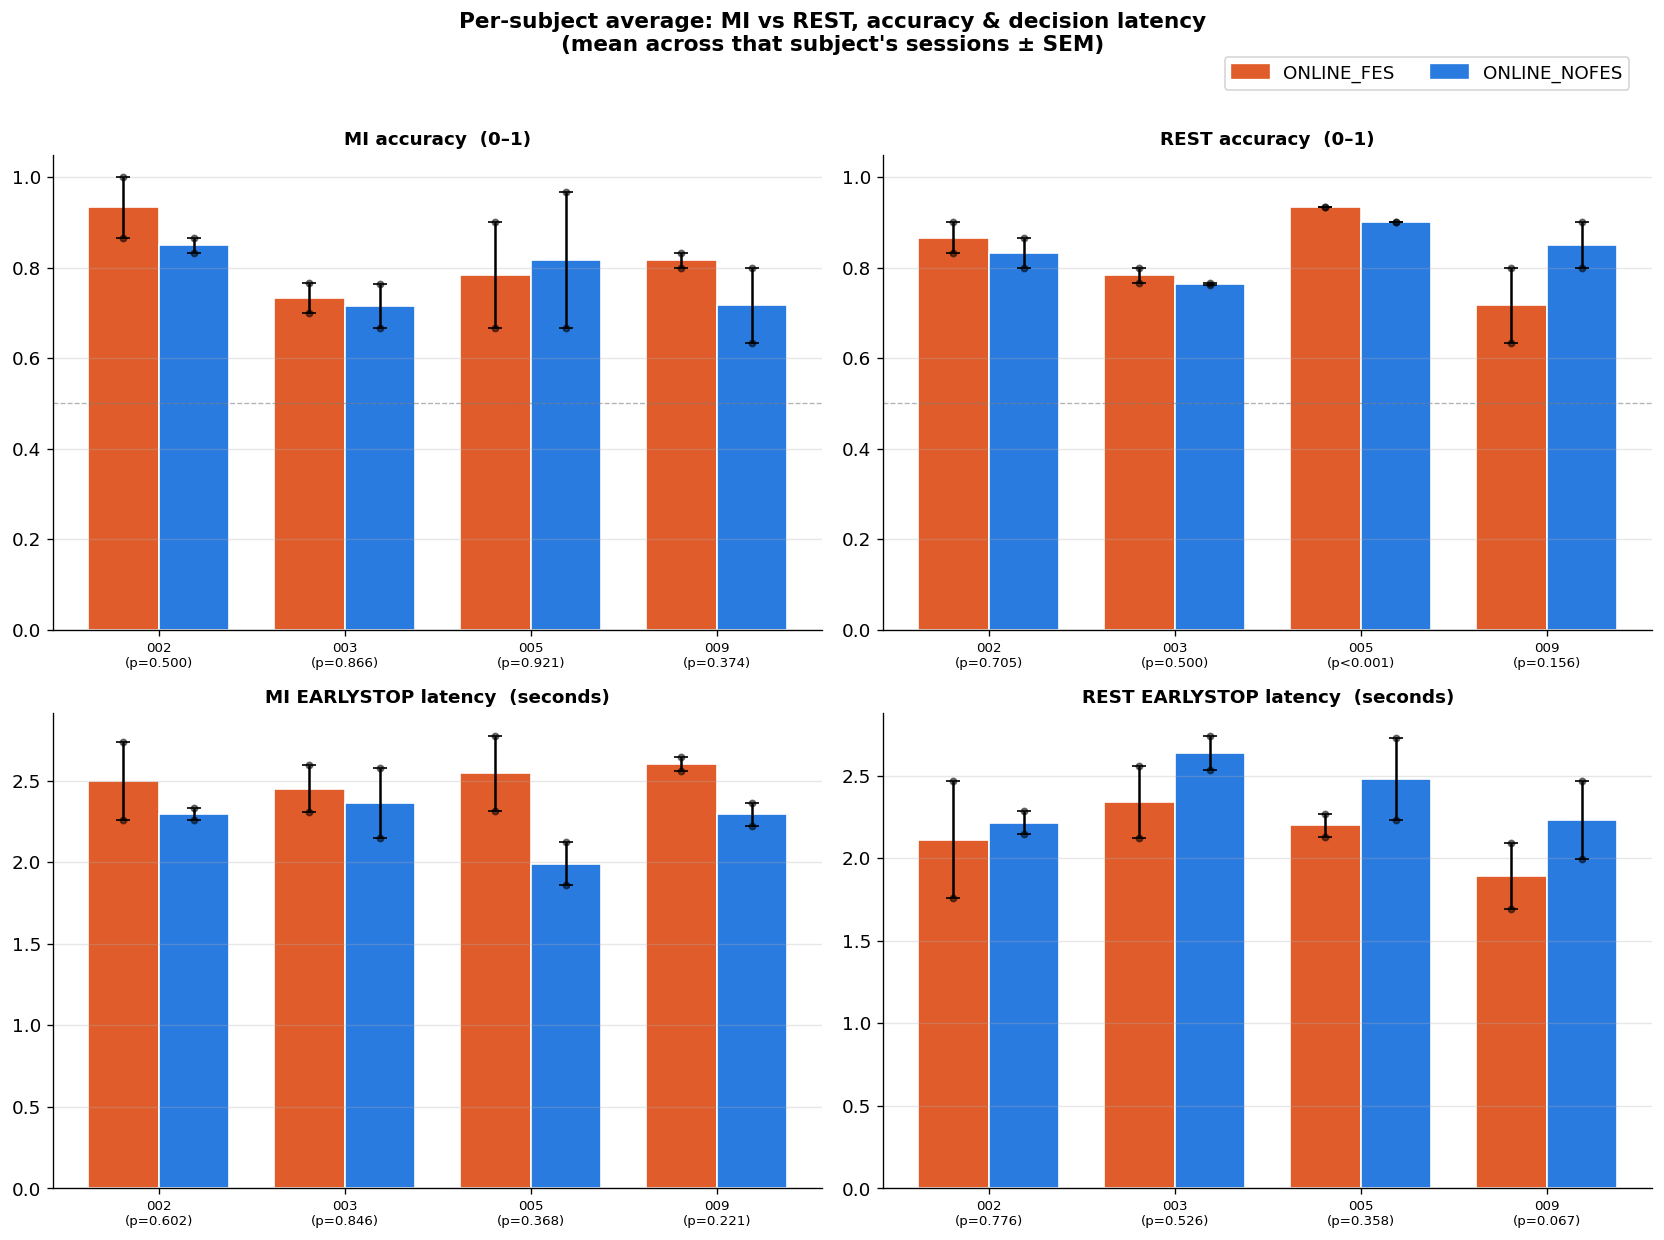

Saved: per_class_acc_latency.png

Per-subject paired Δ = mean(FES) − mean(NOFES) & T-Test:

  MI accuracy:
    subj 002:  FES=0.93  NOFES=0.85  Δ=+0.08   |   p = 0.5000 (t = 1.00, n = 2)
    subj 003:  FES=0.73  NOFES=0.72  Δ=+0.02   |   p = 0.8656 (t = 0.21, n = 2)
    subj 005:  FES=0.78  NOFES=0.82  Δ=-0.03   |   p = 0.9208 (t = -0.12, n = 2)
    subj 009:  FES=0.82  NOFES=0.72  Δ=+0.10   |   p = 0.3743 (t = 1.50, n = 2)

  REST accuracy:
    subj 002:  FES=0.87  NOFES=0.83  Δ=+0.03   |   p = 0.7048 (t = 0.50, n = 2)
    subj 003:  FES=0.78  NOFES=0.76  Δ=+0.02   |   p = 0.5000 (t = 1.00, n = 2)
    subj 005:  FES=0.93  NOFES=0.90  Δ=+0.03   |   p = 0.0000 (t = inf, n = 2)
    subj 009:  FES=0.72  NOFES=0.85  Δ=-0.13   |   p = 0.1560 (t = -4.00, n = 2)

  MI EARLYSTOP latency:
    subj 002:  FES=2.50  NOFES=2.30  Δ=+0.20   |   p = 0.6020 (t = 0.72, n = 2)
    subj 003:  FES=2.45  NOFES=2.36  Δ=+0.09   |   p = 0.8457 (t = 0.25, n = 2)
    subj 005:  FES=2.54  NOFES=1.99  Δ=+0.56   | 

/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [10]:
from scipy.stats import ttest_rel

PER_CLASS_METRICS = [
    ('mi_acc',       'MI accuracy',               '0–1'),
    ('rest_acc',     'REST accuracy',             '0–1'),
    ('mi_latency',   'MI EARLYSTOP latency',      'seconds'),
    ('rest_latency', 'REST EARLYSTOP latency',    'seconds'),
]

# Restructure data to average across multiple sessions (Pairs) for each subject
def subj_cond_metrics(key):
    """Return {subj: {'FES': [vals...], 'NOFES': [vals...]}} using non-null entries in `results`."""
    out = {s: {'FES': [], 'NOFES': []} for s in subjects}
    for r in results:
        v = r.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        out[r['subject']][r['condition']].append(v)
    return out

mi_acc_data = subj_cond_metrics('mi_acc')
rest_acc_data = subj_cond_metrics('rest_acc')
mi_lat_data = subj_cond_metrics('mi_latency')
rest_lat_data = subj_cond_metrics('rest_latency')

metrics_data = [mi_acc_data, rest_acc_data, mi_lat_data, rest_lat_data]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Per-subject average: MI vs REST, accuracy & decision latency\n(mean across that subject\'s sessions ± SEM)',
             fontsize=13, fontweight='bold', y=1.03)

width = 0.38
x = np.arange(len(subjects))

for ax, data_dict, (key, title, unit) in zip(axes.ravel(), metrics_data, PER_CLASS_METRICS):
    for i, cond in enumerate(('FES', 'NOFES')):
        means = [np.mean(data_dict[s][cond]) if data_dict[s][cond] else np.nan for s in subjects]
        sems  = [np.std(data_dict[s][cond], ddof=1) / np.sqrt(len(data_dict[s][cond]))
                 if len(data_dict[s][cond]) > 1 else 0.0 for s in subjects]
        offset = (i - 0.5) * width
        ax.bar(x + offset, means, width, yerr=sems,
               color=cond_color[cond], label=cond, edgecolor='white', capsize=4)
        
        # Overlay individual session values
        for xi, s in zip(x, subjects):
            if data_dict[s][cond]:
                ax.scatter(np.full(len(data_dict[s][cond]), xi + offset), data_dict[s][cond],
                           color='k', alpha=0.5, s=14, zorder=3)
    
    # Calculate p-values for pairs and add them to custom labels
    new_labels = []
    for s in subjects:
        label = s
        if data_dict[s]['FES'] and data_dict[s]['NOFES'] and len(data_dict[s]['FES']) == len(data_dict[s]['NOFES']) and len(data_dict[s]['FES']) > 1:
            try:
                _, p_val = ttest_rel(data_dict[s]['FES'], data_dict[s]['NOFES'])
                p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
                label = f'{s}\n({p_str})'
            except Exception:
                pass
        new_labels.append(label)

    ax.set_xticks(x)
    ax.set_xticklabels(new_labels, fontsize=8)
    ax.set_title(f'{title}  ({unit})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    if 'acc' in key:
        ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.6)
        ax.set_ylim(0, 1.05)

fig.legend(handles=[Patch(color=cond_color['FES'],   label='ONLINE_FES'),
                    Patch(color=cond_color['NOFES'], label='ONLINE_NOFES')],
           loc='upper right', ncol=2, bbox_to_anchor=(0.98, 1.0))
plt.tight_layout()
plt.savefig('per_class_acc_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_acc_latency.png')

# ── Paired Δ (FES − NOFES) summary per subject ─────────────────────
print('\nPer-subject paired Δ = mean(FES) − mean(NOFES) & T-Test:')
for (key, title, _), data_dict in zip(PER_CLASS_METRICS, metrics_data):
    print(f'\n  {title}:')
    for s in subjects:
        if data_dict[s]['FES'] and data_dict[s]['NOFES']:
            delta = np.mean(data_dict[s]['FES']) - np.mean(data_dict[s]['NOFES'])
            if len(data_dict[s]['FES']) == len(data_dict[s]['NOFES']) and len(data_dict[s]['FES']) > 1:
                t_stat, p_val = ttest_rel(data_dict[s]['FES'], data_dict[s]['NOFES'])
                stats_str = f'p = {p_val:.4f} (t = {t_stat:.2f}, n = {len(data_dict[s]["FES"])})'
            else:
                stats_str = f'n = {len(data_dict[s]["FES"])} (too few paired runs)'
                
            print(f'    subj {s}:  FES={np.mean(data_dict[s]["FES"]):.2f}  '
                  f'NOFES={np.mean(data_dict[s]["NOFES"]):.2f}  Δ={delta:+.2f}   |   {stats_str}')

### Per-subject average latency

Collapses the per-(subject × pair) bars into one FES value and one NOFES value per subject
by averaging across all that subject's ONLINE sessions of each type. Error bars are the
session-to-session SEM within that (subject, condition). Easier to read when you just want
the per-subject FES vs NOFES comparison without the pair split.

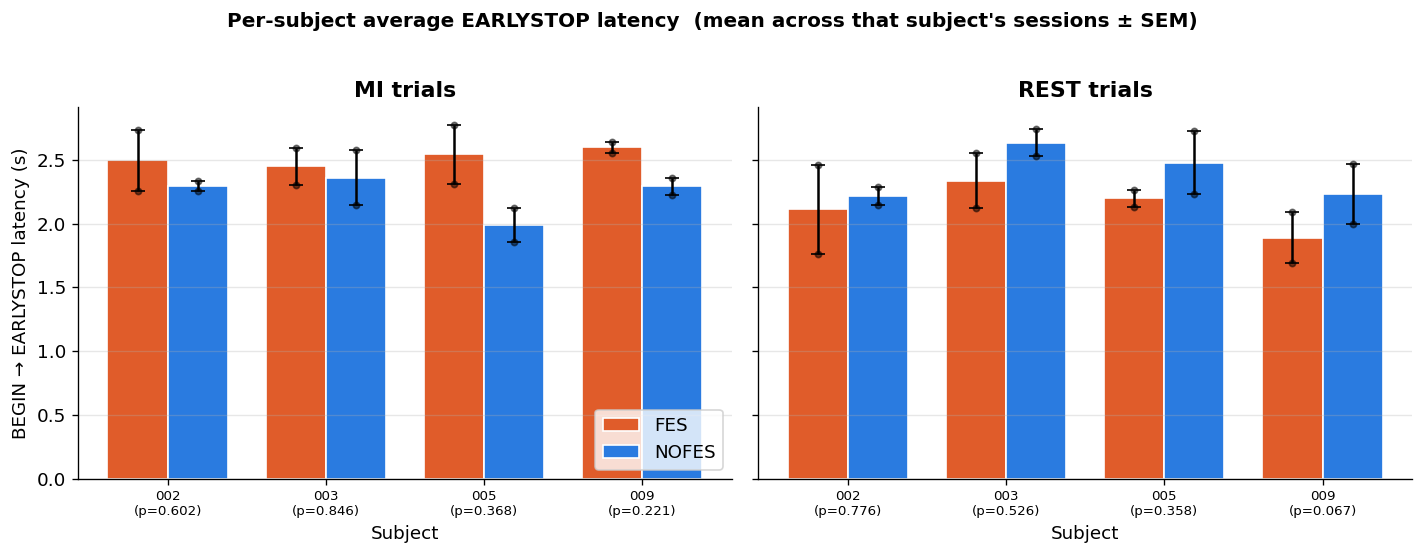

Saved: per_subject_latency.png

Per-subject paired Δ = mean(FES lat) − mean(NOFES lat) & T-Test:
  MI latency:
    subj 002:  FES=2.50s  NOFES=2.30s  Δ=+0.20s   |   p = 0.6020 (t = 0.72, n = 2)
    subj 003:  FES=2.45s  NOFES=2.36s  Δ=+0.09s   |   p = 0.8457 (t = 0.25, n = 2)
    subj 005:  FES=2.54s  NOFES=1.99s  Δ=+0.56s   |   p = 0.3678 (t = 1.53, n = 2)
    subj 009:  FES=2.60s  NOFES=2.29s  Δ=+0.31s   |   p = 0.2213 (t = 2.76, n = 2)
  REST latency:
    subj 002:  FES=2.11s  NOFES=2.22s  Δ=-0.10s   |   p = 0.7758 (t = -0.37, n = 2)
    subj 003:  FES=2.34s  NOFES=2.64s  Δ=-0.30s   |   p = 0.5264 (t = -0.92, n = 2)
    subj 005:  FES=2.20s  NOFES=2.48s  Δ=-0.28s   |   p = 0.3581 (t = -1.59, n = 2)
    subj 009:  FES=1.89s  NOFES=2.23s  Δ=-0.34s   |   p = 0.0667 (t = -9.50, n = 2)


In [11]:
from scipy.stats import ttest_rel

# Average latency per subject across sessions (collapses the pair dimension)
def subj_cond_latencies(key):
    """Return {subj: {'FES': [vals...], 'NOFES': [vals...]}} using all non-null entries in `results`."""
    out = {s: {'FES': [], 'NOFES': []} for s in subjects}
    for r in results:
        v = r.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        out[r['subject']][r['condition']].append(v)
    return out

mi_lat   = subj_cond_latencies('mi_latency')
rest_lat = subj_cond_latencies('rest_latency')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.suptitle('Per-subject average EARLYSTOP latency  (mean across that subject\'s sessions ± SEM)',
             fontsize=12, fontweight='bold', y=1.02)

width = 0.38
x     = np.arange(len(subjects))

for ax, data, title in [(axes[0], mi_lat,   'MI trials'),
                        (axes[1], rest_lat, 'REST trials')]:
    for i, cond in enumerate(('FES', 'NOFES')):
        means = [np.mean(data[s][cond]) if data[s][cond] else np.nan for s in subjects]
        sems  = [np.std(data[s][cond], ddof=1) / np.sqrt(len(data[s][cond]))
                 if len(data[s][cond]) > 1 else 0.0 for s in subjects]
        offset = (i - 0.5) * width
        ax.bar(x + offset, means, width, yerr=sems,
               color=cond_color[cond], label=cond, edgecolor='white', capsize=4)
        # Overlay individual session values
        for xi, s in zip(x, subjects):
            if data[s][cond]:
                ax.scatter(np.full(len(data[s][cond]), xi + offset), data[s][cond],
                           color='k', alpha=0.5, s=14, zorder=3)
                           
    # Calculate and format p-values for x-axis labels
    new_labels = []
    for s in subjects:
        label = s
        if data[s]['FES'] and data[s]['NOFES'] and len(data[s]['FES']) == len(data[s]['NOFES']) and len(data[s]['FES']) > 1:
            try:
                _, p_val = ttest_rel(data[s]['FES'], data[s]['NOFES'])
                p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
                label = f'{s}\n({p_str})'
            except Exception:
                pass
        new_labels.append(label)
                
    ax.set_xticks(x)
    ax.set_xticklabels(new_labels, fontsize=8) # slightly smaller to fit the p-vals
    ax.set_xlabel('Subject')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel('BEGIN → EARLYSTOP latency (s)')
axes[0].legend(loc='lower right')

plt.tight_layout()
plt.savefig('per_subject_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_subject_latency.png')

# Per-subject paired Δ summary
print('\nPer-subject paired Δ = mean(FES lat) − mean(NOFES lat) & T-Test:')
for key, title in [('mi_latency', 'MI'), ('rest_latency', 'REST')]:
    data = subj_cond_latencies(key)
    print(f'  {title} latency:')
    for s in subjects:
        if data[s]['FES'] and data[s]['NOFES']:
            delta = np.mean(data[s]['FES']) - np.mean(data[s]['NOFES'])
            
            # Since data arrays are appended in order (Pair 1, Pair 2), we can run a paired t-test
            # if we have balanced matched pairs (e.g. n=2 for FES and n=2 for NOFES).
            if len(data[s]['FES']) == len(data[s]['NOFES']) and len(data[s]['FES']) > 1:
                t_stat, p_val = ttest_rel(data[s]['FES'], data[s]['NOFES'])
                stats_str = f'p = {p_val:.4f} (t = {t_stat:.2f}, n = {len(data[s]["FES"])})'
            else:
                stats_str = f'n = {len(data[s]["FES"])} (too few or unbalanced runs for paired t-test)'
                
            print(f'    subj {s}:  FES={np.mean(data[s]["FES"]):.2f}s  '
                  f'NOFES={np.mean(data[s]["NOFES"]):.2f}s  Δ={delta:+.2f}s   |   {stats_str}')

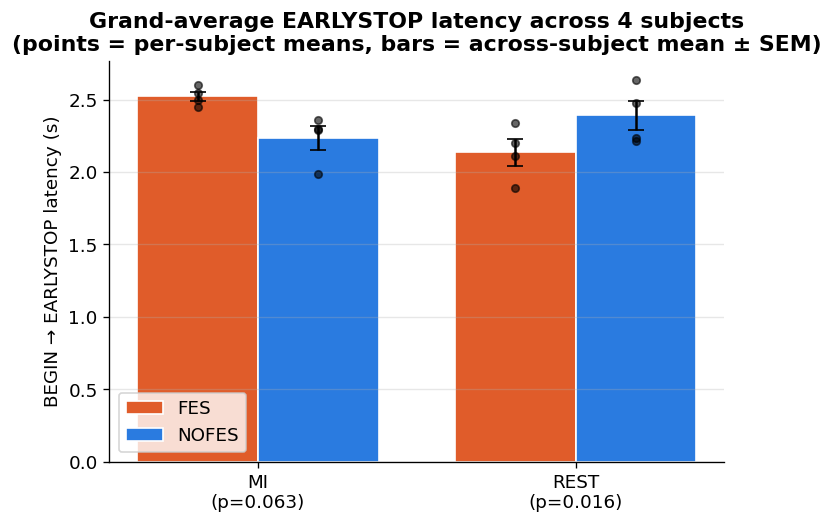

Saved: grand_avg_latency.png

Grand-average latency (across-subject mean ± SEM) & Paired T-Test:
  MI     FES = 2.523 ± 0.032 s   NOFES = 2.235 ± 0.084 s   Δ = +0.288 s   |   p = 0.0632 (t = 2.89, n = 4)
  REST   FES = 2.135 ± 0.094 s   NOFES = 2.391 ± 0.102 s   Δ = -0.256 s   |   p = 0.0163 (t = -4.89, n = 4)


In [12]:
# Grand average across subjects: one pair of bars per class (MI, REST).
# Each subject contributes one mean (averaged across their sessions) per condition,
# so error bars = between-subject SEM.
from scipy.stats import ttest_rel

def subject_means(data):
    return {cond: np.array([np.mean(data[s][cond]) for s in subjects if data[s][cond]])
            for cond in ('FES', 'NOFES')}

mi_sub   = subject_means(mi_lat)
rest_sub = subject_means(rest_lat)

fig, ax = plt.subplots(figsize=(6, 4.5))
classes = ['MI', 'REST']
x       = np.arange(len(classes))
width   = 0.38

p_values = {}
for cls, d in [('MI', mi_sub), ('REST', rest_sub)]:
    subjects_with_both = [s for s in subjects if mi_lat[s]['FES'] and mi_lat[s]['NOFES']] if cls == 'MI' else [s for s in subjects if rest_lat[s]['FES'] and rest_lat[s]['NOFES']]
    fes_paired = np.array([np.mean(mi_lat[s]['FES']) if cls == 'MI' else np.mean(rest_lat[s]['FES']) for s in subjects_with_both])
    nofes_paired = np.array([np.mean(mi_lat[s]['NOFES']) if cls == 'MI' else np.mean(rest_lat[s]['NOFES']) for s in subjects_with_both])
    
    if len(fes_paired) > 1:
        _, p_val = ttest_rel(fes_paired, nofes_paired)
        p_values[cls] = p_val
    else:
        p_values[cls] = np.nan

for i, cond in enumerate(('FES', 'NOFES')):
    means = [mi_sub[cond].mean(),        rest_sub[cond].mean()]
    sems  = [mi_sub[cond].std(ddof=1) / np.sqrt(len(mi_sub[cond])),
             rest_sub[cond].std(ddof=1) / np.sqrt(len(rest_sub[cond]))]
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems,
           color=cond_color[cond], label=cond, edgecolor='white', capsize=5)
    for j, arr in enumerate([mi_sub[cond], rest_sub[cond]]):
        ax.scatter(np.full(len(arr), x[j] + offset), arr,
                   color='k', alpha=0.6, s=20, zorder=3)

# Modify X-labels to contain the P-Values below each
new_labels = []
for cls in classes:
    p_val = p_values[cls]
    if not np.isnan(p_val):
        p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
        new_labels.append(f'{cls}\n({p_str})')
    else:
        new_labels.append(cls)

ax.set_xticks(x); ax.set_xticklabels(new_labels)
ax.set_ylabel('BEGIN → EARLYSTOP latency (s)')
ax.set_title(f'Grand-average EARLYSTOP latency across {len(subjects)} subjects\n'
             '(points = per-subject means, bars = across-subject mean ± SEM)',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grand_avg_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: grand_avg_latency.png')

print('\nGrand-average latency (across-subject mean ± SEM) & Paired T-Test:')
sem = lambda a: a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0
for cls, d in [('MI', mi_sub), ('REST', rest_sub)]:
    # Ensure arrays are aligned for t-test by taking paired subjects only
    subjects_with_both = [s for s in subjects if mi_lat[s]['FES'] and mi_lat[s]['NOFES']] if cls == 'MI' else [s for s in subjects if rest_lat[s]['FES'] and rest_lat[s]['NOFES']]
    
    fes_paired = np.array([np.mean(mi_lat[s]['FES']) if cls == 'MI' else np.mean(rest_lat[s]['FES']) for s in subjects_with_both])
    nofes_paired = np.array([np.mean(mi_lat[s]['NOFES']) if cls == 'MI' else np.mean(rest_lat[s]['NOFES']) for s in subjects_with_both])
    
    delta = d['FES'].mean() - d['NOFES'].mean()
    
    if len(fes_paired) > 1:
        t_stat, p_val = ttest_rel(fes_paired, nofes_paired)
        stats_str = f'p = {p_val:.4f} (t = {t_stat:.2f}, n = {len(fes_paired)})'
    else:
        stats_str = 'Not enough paired data for t-test'
        
    print(f'  {cls:<5}  FES = {d["FES"].mean():.3f} ± {sem(d["FES"]):.3f} s   '
          f'NOFES = {d["NOFES"].mean():.3f} ± {sem(d["NOFES"]):.3f} s   '
          f'Δ = {delta:+.3f} s   |   {stats_str}')

---
## Figure 6 — Decision-margin distribution shift (Wasserstein-1)

Mean |margin| collapses the whole distribution to a scalar. If FES spreads the margin
distribution further from zero (or sharpens it into a narrow high-confidence mode) without
moving the mean, that shows up here but not in mean amplitude. For each (subject × pair),
we compute W₁ between the FES and NOFES margin distributions, separately for MI and REST
trials. Larger W₁ = greater distributional divergence between conditions.

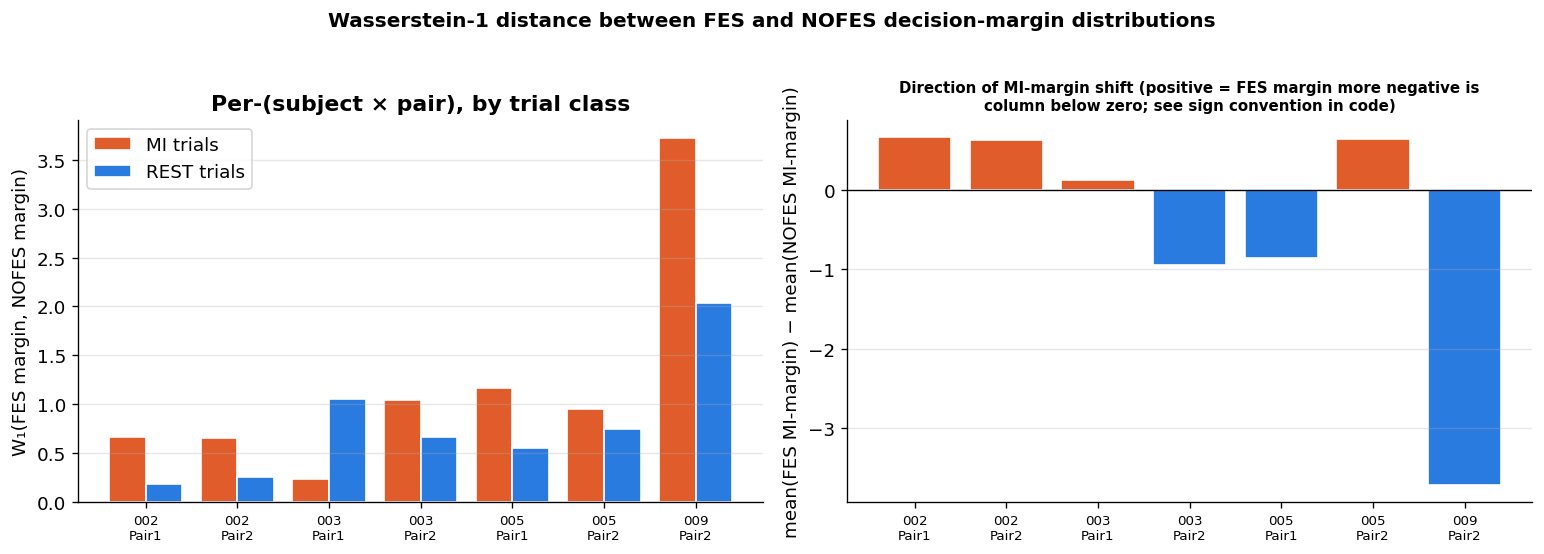

Saved: margin_wasserstein.png

Mean W₁ across 7 (subject × pair) comparisons:
  MI trials:   1.207 ± 1.150
  REST trials: 0.785 ± 0.623
  W₁(MI) > W₁(REST) in 6/7 comparisons — FES perturbs MI margins more than REST margins


In [13]:
w_results = []   # one row per (subject, pair) — Wasserstein between FES and NOFES margin dists
for subj in subjects:
    for pair in PAIRS:
        fes = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='FES'),   None)
        nof = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='NOFES'), None)
        if fes is None or nof is None: continue
        if fes['margin'].size == 0 or nof['margin'].size == 0: continue

        def w1(fe_mask, no_mask):
            f = fes['margin'][fe_mask];  n = nof['margin'][no_mask]
            return wasserstein_distance(f, n) if (f.size and n.size) else np.nan

        w_results.append(dict(
            subject=subj, pair=pair['name'].split()[0],
            w_mi   = w1(fes['y_test'] == 1, nof['y_test'] == 1),
            w_rest = w1(fes['y_test'] == 0, nof['y_test'] == 0),
            w_all  = wasserstein_distance(fes['margin'], nof['margin']),
            fes_mi_mean   = fes['margin'][fes['y_test']==1].mean() if (fes['y_test']==1).any() else np.nan,
            nofes_mi_mean = nof['margin'][nof['y_test']==1].mean() if (nof['y_test']==1).any() else np.nan,
        ))

if w_results:
    labels  = [f'{r["subject"]}\n{r["pair"]}' for r in w_results]
    w_mi    = np.array([r['w_mi']   for r in w_results])
    w_rest  = np.array([r['w_rest'] for r in w_results])
    x = np.arange(len(labels))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle('Wasserstein-1 distance between FES and NOFES decision-margin distributions',
                 fontsize=12, fontweight='bold', y=1.02)

    width = 0.4
    axes[0].bar(x - width/2, w_mi,   width, color='#E05C2A', label='MI trials',   edgecolor='white')
    axes[0].bar(x + width/2, w_rest, width, color='#2A7BE0', label='REST trials', edgecolor='white')
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
    axes[0].set_ylabel('W₁(FES margin, NOFES margin)')
    axes[0].set_title('Per-(subject × pair), by trial class', fontweight='bold')
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    # Direction of the shift (FES mean − NOFES mean) on MI margins
    fes_mi    = np.array([r['fes_mi_mean']   for r in w_results])
    nofes_mi  = np.array([r['nofes_mi_mean'] for r in w_results])
    mi_shift  = fes_mi - nofes_mi
    colors_sh = ['#E05C2A' if d > 0 else '#2A7BE0' for d in mi_shift]
    axes[1].bar(x, mi_shift, color=colors_sh, edgecolor='white')
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_ylabel('mean(FES MI-margin) − mean(NOFES MI-margin)')
    axes[1].set_title('Direction of MI-margin shift (positive = FES margin more negative is\ncolumn below zero; see sign convention in code)', fontsize=9, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('margin_wasserstein.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: margin_wasserstein.png')

    print(f'\nMean W₁ across {len(w_results)} (subject × pair) comparisons:')
    print(f'  MI trials:   {np.nanmean(w_mi):.3f} ± {np.nanstd(w_mi, ddof=1):.3f}')
    print(f'  REST trials: {np.nanmean(w_rest):.3f} ± {np.nanstd(w_rest, ddof=1):.3f}')
    print(f'  W₁(MI) > W₁(REST) in {int((w_mi > w_rest).sum())}/{len(w_results)} comparisons '
          f'— FES perturbs MI margins more than REST margins')
else:
    print('No comparisons available for Wasserstein analysis.')

---
## Summary Statistics

---
## Figure 4 — Within-session MI-accuracy trajectory (sliding window)

Refined from the original "thirds" analysis to address its noise floor. Each online session
is parsed into chronological MI-only trials, then a W-trial sliding window gives a smoother
accuracy trajectory. The slope of a linear fit to this trajectory is a per-session "learning
rate." Restricting to MI trials isolates the class that FES actually perturbs (orthotic +
stimulation fires on MI, not REST) — slope differences between FES and NOFES sessions would
indicate whether proprioceptive feedback accelerates within-session adaptation.

Caveat: even with sliding windows, ~25–30 MI trials per session is low-N and the slope
estimator is noisy; read this as exploratory, not confirmatory.

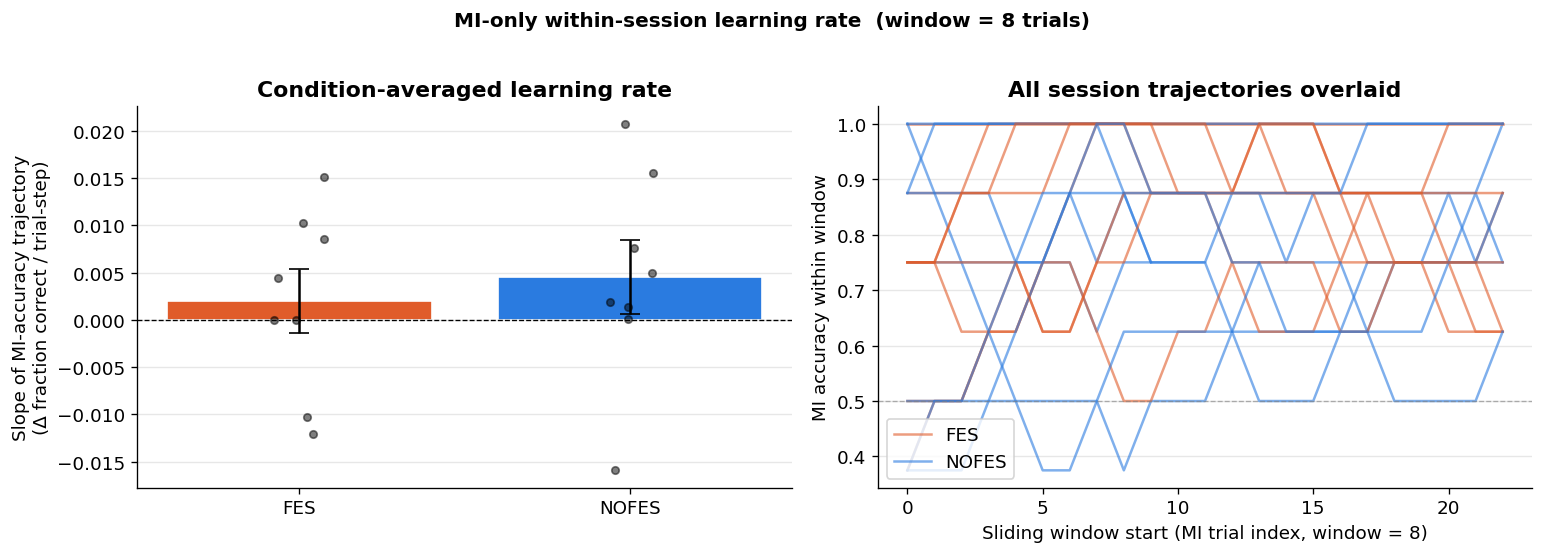

Saved: within_session_mi_trajectory.png

Condition-averaged slopes (FES − NOFES paired per session):
  FES:   mean slope = +0.0020  (n=8)
  NOFES: mean slope = +0.0045  (n=8)


In [14]:
WINDOW = 8   # trials per sliding window

lr_results = []
for r in results:
    mi_successes = np.array([int(t['success']) for t in r['trials'] if t['cls'] == 'MI'])
    if len(mi_successes) < WINDOW + 2:
        continue
    traj = np.array([mi_successes[i:i+WINDOW].mean()
                     for i in range(len(mi_successes) - WINDOW + 1)])
    slope = np.polyfit(np.arange(len(traj)), traj, 1)[0]
    lr_results.append(dict(subj=r['subject'], pair=r['pair'], cond=r['condition'],
                           traj=traj, slope=slope, n_mi=len(mi_successes)))

# ── Figure 4a: slope per condition (FES vs NOFES) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f'MI-only within-session learning rate  (window = {WINDOW} trials)',
             fontsize=12, fontweight='bold', y=1.02)

fes_slopes   = np.array([r['slope'] for r in lr_results if r['cond'] == 'FES'])
nofes_slopes = np.array([r['slope'] for r in lr_results if r['cond'] == 'NOFES'])

ax = axes[0]
means  = [fes_slopes.mean(), nofes_slopes.mean()]
sems   = [fes_slopes.std(ddof=1) / np.sqrt(len(fes_slopes)),
          nofes_slopes.std(ddof=1) / np.sqrt(len(nofes_slopes))]
ax.bar(['FES', 'NOFES'], means, yerr=sems,
       color=[cond_color['FES'], cond_color['NOFES']],
       capsize=6, edgecolor='white')
# Overlay individual points
for i, slopes in enumerate([fes_slopes, nofes_slopes]):
    ax.scatter(np.full(len(slopes), i) + np.random.uniform(-0.08, 0.08, len(slopes)),
               slopes, color='k', alpha=0.5, s=20, zorder=3)
ax.axhline(0, color='k', linestyle='--', lw=0.8)
ax.set_ylabel('Slope of MI-accuracy trajectory\n(Δ fraction correct / trial-step)')
ax.set_title('Condition-averaged learning rate', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# ── Figure 4b: trajectories per (subject × pair) ─────────────────────────────
ax = axes[1]
for r in lr_results:
    ax.plot(r['traj'], color=cond_color[r['cond']], alpha=0.6, lw=1.5,
            label=r['cond'])
ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax.set_xlabel(f'Sliding window start (MI trial index, window = {WINDOW})')
ax.set_ylabel('MI accuracy within window')
ax.set_title('All session trajectories overlaid', fontweight='bold')
# Dedup legend
h, l = ax.get_legend_handles_labels()
seen = set()
handles = [(hh, ll) for hh, ll in zip(h, l) if not (ll in seen or seen.add(ll))]
ax.legend([h for h, _ in handles], [l for _, l in handles], loc='lower left')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('within_session_mi_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: within_session_mi_trajectory.png')
print(f'\nCondition-averaged slopes (FES − NOFES paired per session):')
print(f'  FES:   mean slope = {fes_slopes.mean():+.4f}  (n={len(fes_slopes)})')
print(f'  NOFES: mean slope = {nofes_slopes.mean():+.4f}  (n={len(nofes_slopes)})')

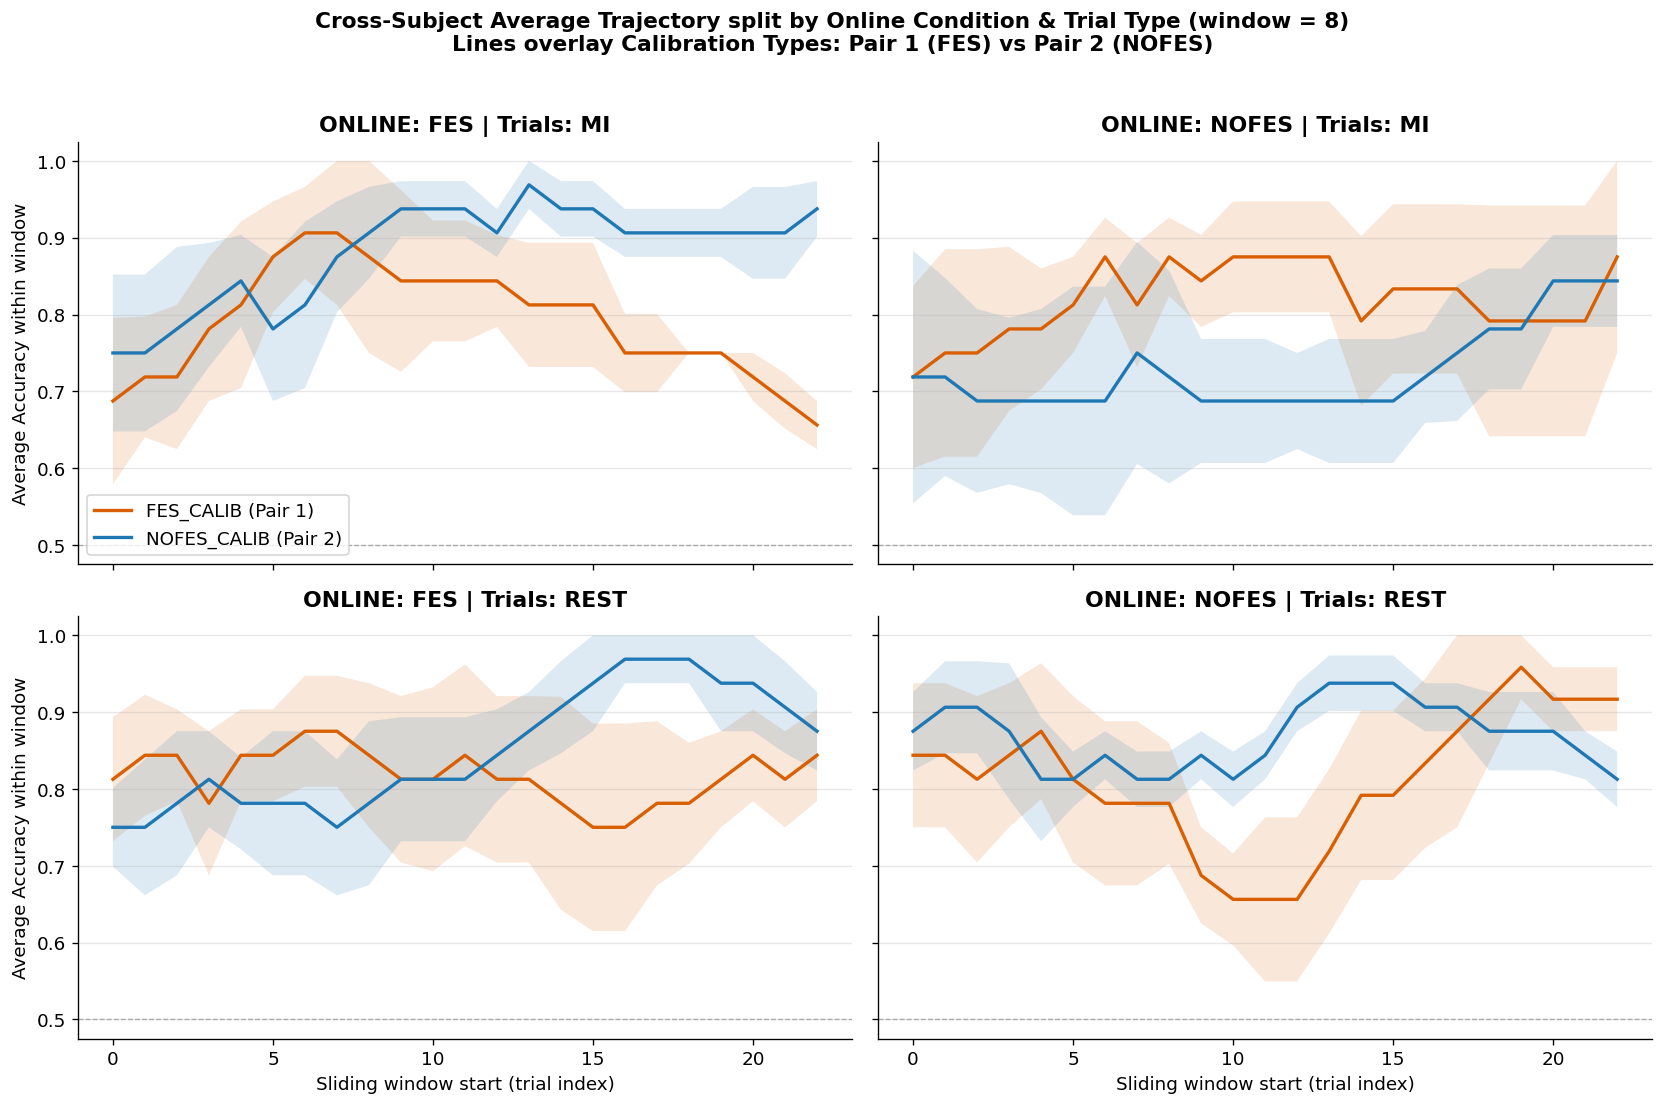

Saved: avg_within_session_trajectory_cross_overlay.png


In [16]:
# Re-calculate trajectories for BOTH MI and REST trials to support the requested 2x2 overlay
WINDOW_BOTH = 8

lr_results_all = []
for r in results:
    for trial_type in ['MI', 'REST']:
        successes = np.array([int(t['success']) for t in r['trials'] if t['cls'] == trial_type])
        if len(successes) < WINDOW_BOTH + 2:
            continue
        traj = np.array([successes[i:i+WINDOW_BOTH].mean()
                         for i in range(len(successes) - WINDOW_BOTH + 1)])
        lr_results_all.append(dict(
            subj=r['subject'], pair=r['pair'], cond=r['condition'], 
            trial_type=trial_type, traj=traj
        ))

# Create a 2x2 grid: Rows = MI vs REST, Cols = ONLINE FES vs ONLINE NOFES
# In each subplot, overlay Pair 1 (FES CALIB) vs Pair 2 (NOFES CALIB)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True, sharex=True)
fig.suptitle(f'Cross-Subject Average Trajectory split by Online Condition & Trial Type (window = {WINDOW_BOTH})\n'
             'Lines overlay Calibration Types: Pair 1 (FES) vs Pair 2 (NOFES)',
             fontsize=13, fontweight='bold', y=1.02)

TRIAL_TYPES = ['MI', 'REST']
ONLINE_CONDS = ['FES', 'NOFES']

# Define distinct line colors / styles for the Calibration pairs to avoid confusion with Online Conds
# Pair 1 (FES_CALIB) -> dark orange-ish
# Pair 2 (NOFES_CALIB) -> dark blue-ish
calib_style = {
    'Pair1': {'color': '#d95f02', 'label': 'FES_CALIB (Pair 1)'},
    'Pair2': {'color': '#1f78b4', 'label': 'NOFES_CALIB (Pair 2)'}
}

import warnings

for row_idx, trial_type in enumerate(TRIAL_TYPES):
    for col_idx, online_cond in enumerate(ONLINE_CONDS):
        ax = axes[row_idx, col_idx]
        
        for pair_prefix, style_info in calib_style.items():
            # Extract trajectories matching this specific combination:
            # (trial_type, online_cond, pair starts with Pair1 or Pair2)
            match_subset = [r['traj'] for r in lr_results_all 
                            if r['trial_type'] == trial_type 
                            and r['cond'] == online_cond 
                            and r['pair'].startswith(pair_prefix)]
            
            if not match_subset:
                continue
                
            max_len = max(len(t) for t in match_subset)
            padded = np.full((len(match_subset), max_len), np.nan)
            for j, t in enumerate(match_subset):
                padded[j, :len(t)] = t
                
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                mean_traj = np.nanmean(padded, axis=0)
                n_present = np.sum(~np.isnan(padded), axis=0)
                sem_traj = np.nanstd(padded, axis=0, ddof=1) / np.sqrt(n_present)
                
            x_vals = np.arange(max_len)
            ax.plot(x_vals, mean_traj, color=style_info['color'], label=style_info['label'], lw=2)
            ax.fill_between(x_vals, mean_traj - sem_traj, mean_traj + sem_traj, 
                            color=style_info['color'], alpha=0.15, edgecolor='none')
            
        ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.6)
        ax.set_title(f'ONLINE: {online_cond} | Trials: {trial_type}', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
        
        if row_idx == 1:
            ax.set_xlabel('Sliding window start (trial index)')
        if col_idx == 0:
            ax.set_ylabel('Average Accuracy within window')
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig('avg_within_session_trajectory_cross_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: avg_within_session_trajectory_cross_overlay.png')

In [17]:
def boot_paired_ci(deltas, n_boot=10000, alpha=0.05, seed=0):
    """Bootstrap percentile CI on the mean of paired differences."""
    rng = np.random.default_rng(seed)
    d = np.asarray([x for x in deltas if x is not None and not (isinstance(x, float) and np.isnan(x))])
    if len(d) == 0:
        return (np.nan, np.nan, np.nan)
    boot_means = d[rng.integers(0, len(d), size=(n_boot, len(d)))].mean(axis=1)
    lo, hi = np.percentile(boot_means, [100*alpha/2, 100*(1-alpha/2)])
    return float(d.mean()), float(lo), float(hi)


# Collect all (subject × pair) where both FES and NOFES exist
paired = []
for subj in subjects:
    for pair in PAIRS:
        fes = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='FES'),   None)
        nof = next((r for r in results if r['subject']==subj and r['pair']==pair['name']
                    and r['condition']=='NOFES'), None)
        if fes and nof: paired.append((fes, nof))

print(f'=== Aggregate across {len(paired)} complete (subject × pair) comparisons ===\n')

METRICS_SUMMARY = [
    ('acc',          'Overall accuracy (markers)'),
    ('mi_acc',       'MI accuracy'),
    ('rest_acc',     'REST accuracy'),
    ('mi_latency',   'MI EARLYSTOP latency (s)'),
    ('rest_latency', 'REST EARLYSTOP latency (s)'),
    ('amp',          'Classification amplitude'),
    ('fisher',       'Fisher ratio (test SNR)'),
    ('mu_snr',       'μ-band SNR (REST/MI)'),
]

hdr = (f'{"Metric":<28} {"FES":>18} {"NOFES":>18} '
       f'{"paired Δ":>9} {"95% CI (bootstrap)":>24} {"sign":>10}')
print(hdr); print('-' * len(hdr))

def fmt_mean_sd(arr):
    a = np.array([x for x in arr if x is not None and not (isinstance(x, float) and np.isnan(x))])
    if len(a) == 0: return '       --        '
    sd = a.std(ddof=1) if len(a) > 1 else 0.0
    return f'{a.mean():>8.3f} ± {sd:6.3f}'

for k, label in METRICS_SUMMARY:
    fes_v = [f[k] for f, _ in paired]
    nof_v = [n[k] for _, n in paired]
    deltas = [f - n for f, n in zip(fes_v, nof_v)
              if f is not None and n is not None
              and not (isinstance(f, float) and np.isnan(f))
              and not (isinstance(n, float) and np.isnan(n))]
    if not deltas:
        print(f'{label:<28} {"(no data)":<18} {"":<18}')
        continue
    mean_d, lo, hi = boot_paired_ci(deltas)
    d_arr = np.array(deltas)
    n_pos, n_neg = int((d_arr > 0).sum()), int((d_arr < 0).sum())
    ci_crosses_zero = (lo < 0 < hi)
    marker = '  ' if ci_crosses_zero else ' *'
    print(f'{label:<28} {fmt_mean_sd(fes_v):>18} {fmt_mean_sd(nof_v):>18} '
          f'{mean_d:>+9.3f} [{lo:>+7.3f},{hi:>+7.3f}]{marker}  '
          f'{n_pos}/{n_pos+n_neg}')

print('\n* = 95% bootstrap CI excludes zero (suggestive at this n).')
print('Sign column: number of (subject × pair) comparisons where FES > NOFES.')

=== Aggregate across 8 complete (subject × pair) comparisons ===

Metric                                      FES              NOFES  paired Δ       95% CI (bootstrap)       sign
----------------------------------------------------------------------------------------------------------------
Overall accuracy (markers)       0.821 ±  0.077     0.806 ±  0.075    +0.015 [ -0.040, +0.065]    4/7
MI accuracy                      0.817 ±  0.108     0.775 ±  0.115    +0.042 [ -0.079, +0.142]    5/7
REST accuracy                    0.825 ±  0.100     0.837 ±  0.061    -0.012 [ -0.070, +0.039]    4/7
MI EARLYSTOP latency (s)         2.523 ±  0.204     2.235 ±  0.209    +0.288 [ +0.058, +0.530] *  6/8
REST EARLYSTOP latency (s)       2.135 ±  0.303     2.391 ±  0.270    -0.256 [ -0.416, -0.077] *  2/8
Classification amplitude         2.237 ±  2.063     2.362 ±  1.813    +0.151 [ -0.142, +0.476]    4/7
Fisher ratio (test SNR)          2.307 ±  2.712     2.542 ±  3.263    +0.090 [ -1.065, +1.225]  

## Riemannian Generic Recentering & Discriminability

To investigate whether discriminability changes resulting from FES feedback are hidden by pure accuracy levels, we replicate the robust transfer learning baseline (Riemannian Generic recentering, e.g., Zanini et al., 2018). 

Here we calculated a parameter-independent discriminability metric mathematically isolated from the fixed CSP projections. For each session, covariances are calculated and trace-normalized. We define the global reference point $C_{ref}$ as the Riemannian mean of the resting state trials and calculate discriminability as the native distance between class centers: $\delta_R(C_{MI}, C_{REST})$ upon the Riemannian manifold of SPD matrices.

By projecting each session's testing data to the identity $C_{ref}^{-1/2} X$, the identical offline decoder is evaluated on harmonized session distributions.

<>:157: SyntaxWarning: invalid escape sequence '\d'
<>:157: SyntaxWarning: invalid escape sequence '\d'
/var/folders/98/qwcfyxcd0c12f9zp2wjlf1x80000gn/T/ipykernel_41885/1640400890.py:157: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Riemannian distance (MI vs REST)\n$\delta_R(C_{MI}, C_{REST})$')
/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.9375691313508494e-13
  return f(*arrays, *other_args, **kwargs)
/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.669963803608868e-13
  return f(*arrays, *other_args, **kwargs)
/Users/adipu/ECE374N/Final Project/venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.645524816095128e-13
  return f(*arrays, *other_args, **kwargs)
/Users/adi

=== Riemannian Alignment & Discriminability Metrics ===

Metric                                      FES              NOFES  paired Δ            95% CI (boot)
-----------------------------------------------------------------------------------------------------
Riemannian MI–REST Distance      1.702 ±  0.588     1.687 ±  0.422    +0.016 [ -0.395, +0.371]  
Aligned CSPLDA test acc          0.690 ±  0.147     0.705 ±  0.197    -0.015 [ -0.101, +0.070]  


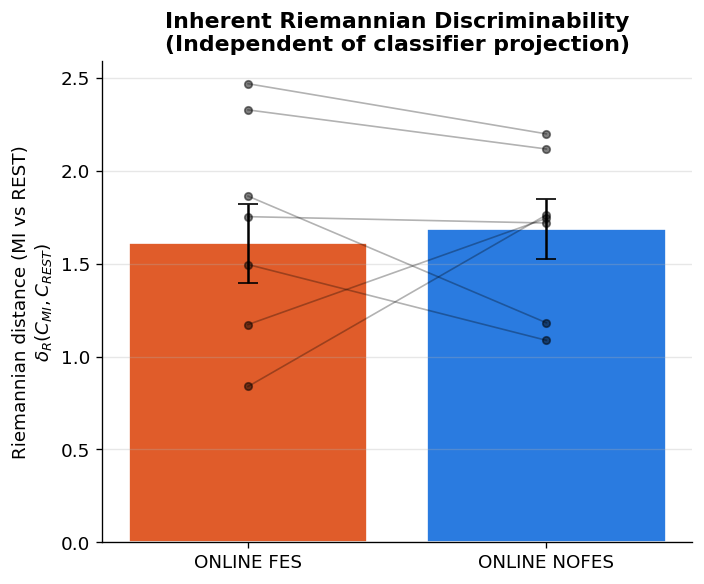


Saved: riemannian_discriminability.png


In [20]:
from scipy.linalg import sqrtm, logm, eigh, inv, norm, expm

def riemannian_mean_cov(covs, tol=1e-5, max_iter=30):
    """Compute Riemannian mean of SPD matrices using iterative fixed-point algorithm."""
    covs = [np.asarray(C, dtype=np.float64) for C in covs]
    # Add small regularization to ensure SPD
    for i in range(len(covs)):
        covs[i] = covs[i] + 1e-5 * np.trace(covs[i]) / covs[i].shape[0] * np.eye(covs[i].shape[0])
    C_mean = np.mean(covs, axis=0) # Init with Euclidean mean
    for _ in range(max_iter):
        C_sq_inv = inv(sqrtm(C_mean))
        tangent_sum = np.zeros_like(C_mean)
        for C in covs:
            tangent_sum += np.real(logm(C_sq_inv @ C @ C_sq_inv))
        tangent_sum /= len(covs)
        
        C_mean = sqrtm(C_mean) @ expm(tangent_sum) @ sqrtm(C_mean)
        C_mean = np.real(C_mean)
        if norm(tangent_sum) < tol:
            break
    return C_mean

def riemannian_dist(A, B):
    """Riemannian distance between symmetric positive-definite matrices A and B."""
    A_reg = A + 1e-6 * np.trace(A) / A.shape[0] * np.eye(A.shape[0])
    B_reg = B + 1e-6 * np.trace(B) / B.shape[0] * np.eye(B.shape[0])
    evals = np.clip(np.real(eigh(A_reg, B_reg, eigvals_only=True)), 1e-12, np.inf)
    return np.sqrt(np.sum(np.log(evals)**2))

def recenter_data(X, y):
    """
    Riemannian Generic Recentering (Zanini et al. 2018).
    Calculates reference covariance C_ref from resting state (y=0)
    and transforms X -> R @ X where R = C_ref^{-1/2}
    """
    # compute trace-normalized covariances
    covs = np.einsum('ijk,ilk->ijl', X, X)
    covs /= np.trace(covs, axis1=1, axis2=2)[:, None, None]
    
    covs_rest = covs[y == 0]
    if len(covs_rest) == 0:
        return X, None, np.nan
        
    C_ref = riemannian_mean_cov(covs_rest)
    
    # Alignment transformation R = C_ref^{-1/2}
    R = np.real(inv(sqrtm(C_ref)))
    X_aligned = np.einsum('ij,kjl->kil', R, X)
    
    # Riemannian discriminability (Distance between MI center and REST center)
    covs_mi = covs[y == 1]
    if len(covs_mi) > 0:
        C_mi = riemannian_mean_cov(covs_mi)
        dist = riemannian_dist(C_mi, C_ref)
    else:
        dist = np.nan
        
    return X_aligned, C_ref, dist

MIN_TEST_TRIALS = 10
ra_results = []

for subj in subjects:
    subj_ses = sessions[subj]
    for pair in PAIRS:
        needed = (pair['train'], pair['online_fes'], pair['online_nofes'])
        if any(k not in subj_ses for k in needed): continue
        
        train = subj_ses[pair['train']]
        if set(np.unique(train['y'])) != {0, 1}: continue
        
        # 1. Recenter Training data
        X_train_r, _, _ = recenter_data(train['X'], train['y'])
        
        # 2. Fit CSPLDA on recentered offline train data
        clf = CSPLDA(n_csp=N_CSP).fit(X_train_r, train['y'])
        train_acc = (clf.predict(X_train_r) == train['y']).mean()
        
        for cond_key, cond_label in [('online_fes', 'FES'), ('online_nofes', 'NOFES')]:
            te = subj_ses[pair[cond_key]]
            if len(te['y']) < MIN_TEST_TRIALS or set(np.unique(te['y'])) != {0, 1}: continue
            
            # 3. Recenter Testing data (Online sets)
            X_test_r, _, riemann_dist = recenter_data(te['X'], te['y'])
            
            # 4. Evaluate decoder on recentered test data
            res = evaluate(clf, X_test_r, te['y'])
            
            y_true = res['y']
            y_pred = res['pred']
            acc = (y_true == y_pred).mean()
            mi_acc = (y_pred[y_true == 1] == 1).mean() if (y_true == 1).any() else np.nan
            rest_acc = (y_pred[y_true == 0] == 0).mean() if (y_true == 0).any() else np.nan
            
            ra_results.append({
                'subject': subj,
                'pair': pair['name'],
                'condition': cond_label,
                'train_acc': train_acc,
                'test_acc': acc,
                'mi_acc': mi_acc,
                'rest_acc': rest_acc,
                'riemann_dist': riemann_dist
            })

print("=== Riemannian Alignment & Discriminability Metrics ===\n")
hdr = f'{"Metric":<28} {"FES":>18} {"NOFES":>18} {"paired Δ":>9} {"95% CI (boot)":>24}'
print(hdr); print('-'*len(hdr))

def fmt_ra(arr):
    if len(arr) == 0: return ' -- '
    return f'{np.mean(arr):>8.3f} ± {np.std(arr, ddof=1):6.3f}'

metrics = [
    ('riemann_dist', 'Riemannian MI–REST Distance'),
    ('test_acc', 'Aligned CSPLDA test acc')
]

for m_key, m_label in metrics:
    fes_vals, nof_vals, deltas = [], [], []
    for subj in subjects:
        for pair in PAIRS:
            fes = next((r for r in ra_results if r['subject']==subj and r['pair']==pair['name'] and r['condition']=='FES'), None)
            nof = next((r for r in ra_results if r['subject']==subj and r['pair']==pair['name'] and r['condition']=='NOFES'), None)
            if fes and nof and not np.isnan(fes[m_key]) and not np.isnan(nof[m_key]):
                fes_vals.append(fes[m_key])
                nof_vals.append(nof[m_key])
                deltas.append(fes[m_key] - nof[m_key])
    
    if len(deltas) > 0:
        mean_d, lo, hi = boot_paired_ci(deltas)
        marker = '  ' if lo < 0 < hi else ' *'
        print(f'{m_label:<28} {fmt_ra(fes_vals):>18} {fmt_ra(nof_vals):>18} '
              f'{mean_d:>+9.3f} [{lo:>+7.3f},{hi:>+7.3f}]{marker}')

# Plot Riemannian Distance (Discriminability) distribution
fes_dists = [r['riemann_dist'] for r in ra_results if r['condition'] == 'FES']
nof_dists = [r['riemann_dist'] for r in ra_results if r['condition'] == 'NOFES']

if fes_dists and nof_dists:
    fig, ax = plt.subplots(figsize=(6, 5))
    means = [np.mean(fes_dists), np.mean(nof_dists)]
    sems = [np.std(fes_dists, ddof=1)/np.sqrt(len(fes_dists)),
            np.std(nof_dists, ddof=1)/np.sqrt(len(nof_dists))]
    ax.bar(['ONLINE FES', 'ONLINE NOFES'], means, yerr=sems, 
           color=[cond_color['FES'], cond_color['NOFES']], capsize=6, edgecolor='white')

    # Paired lines
    for subj in subjects:
        for pair in PAIRS:
            fes = next((r for r in ra_results if r['subject']==subj and r['pair']==pair['name'] and r['condition']=='FES'), None)
            nof = next((r for r in ra_results if r['subject']==subj and r['pair']==pair['name'] and r['condition']=='NOFES'), None)
            if fes and nof:
                ax.plot([0, 1], [fes['riemann_dist'], nof['riemann_dist']], color='k', alpha=0.3, lw=1)
                ax.scatter([0, 1], [fes['riemann_dist'], nof['riemann_dist']], color='k', alpha=0.5, s=20, zorder=3)

    ax.set_ylabel('Riemannian distance (MI vs REST)\n$\delta_R(C_{MI}, C_{REST})$')
    ax.set_title('Inherent Riemannian Discriminability\n(Independent of classifier projection)', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('riemannian_discriminability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved: riemannian_discriminability.png')

## Nonstationarity: Drift from Offline Calibration to Online Session

This analysis measures the covariate shift (drift) by calculating the Riemannian distance between the class manifold in the offline calibration session and the class manifold in the subsequent online session. 
- **FES Drift:** Distance from OFFLINE_FES to ONLINE_FES
- **NOFES Drift:** Distance from OFFLINE_NOFES to ONLINE_NOFES

This is done separately for the MI state and the REST state. High distances indicate that the brain state during the online task has drifted significantly from what the classifier learned during the offline phase.

<>:112: SyntaxWarning: invalid escape sequence '\d'
<>:112: SyntaxWarning: invalid escape sequence '\d'
/var/folders/98/qwcfyxcd0c12f9zp2wjlf1x80000gn/T/ipykernel_41885/2712111310.py:112: SyntaxWarning: invalid escape sequence '\d'
  axes[0].set_ylabel('Riemannian distance (Offline vs Online)\n$\delta_R(C_{train}, C_{test})$')


=== Offline to Online Nonstationarity (Riemannian Drift) ===

Metric                                      FES              NOFES  paired Δ            95% CI (boot)
-----------------------------------------------------------------------------------------------------
MI Drift (Offline->Online)       2.470 ±  1.075     2.248 ±  0.935    +0.222 [ -0.245, +0.869]  
REST Drift (Offline->Online)     2.534 ±  1.087     2.354 ±  0.987    +0.180 [ -0.375, +0.836]  


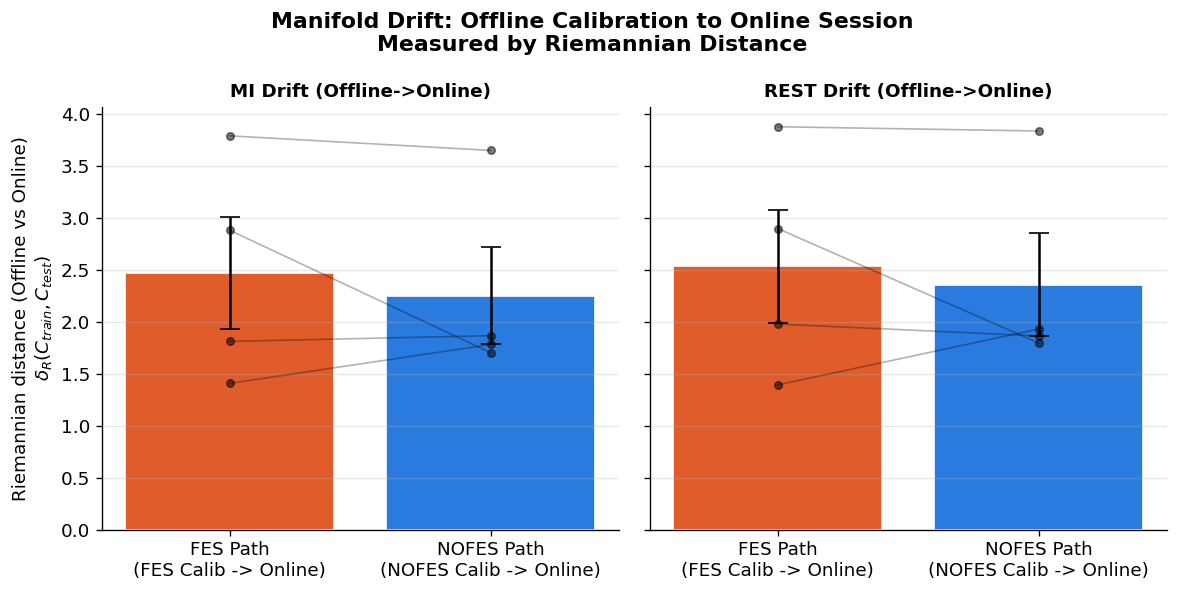


Saved: riemannian_drift_offline_to_online.png


In [23]:
drift_results = []

for subj in subjects:
    subj_ses = sessions[subj]
    
    # We want to measure the drift from offline to the corresponding online session:
    # 1. FES Drift: OFFLINE_FES -> ONLINE_FES
    # 2. NOFES Drift: OFFLINE_NOFES -> ONLINE_NOFES
    drift_pairs = [
        ('FES', PAIRS[0]['train'], PAIRS[0]['online_fes']),       
        ('NOFES', PAIRS[1]['train'], PAIRS[1]['online_nofes'])    
    ]
    
    for cond_label, train_key, test_key in drift_pairs:
        if train_key not in subj_ses or test_key not in subj_ses:
            continue
            
        train = subj_ses[train_key]
        test = subj_ses[test_key]
        
        # Internal helper to calculate regularized trace-normalized covariances
        def get_covs(X):
            c = np.einsum('ijk,ilk->ijl', X, X)
            c /= np.trace(c, axis1=1, axis2=2)[:, None, None]
            # Add small regularization to ensure they are SPD for the Riemannian distance
            for i in range(len(c)):
                c[i] = c[i] + 1e-5 * np.trace(c[i]) / c[i].shape[0] * np.eye(c[i].shape[0])
            return c

        train_covs = get_covs(train['X'])
        test_covs = get_covs(test['X'])
        
        # Pull out the MI and REST manifolds
        train_mi, train_rest = train_covs[train['y'] == 1], train_covs[train['y'] == 0]
        test_mi, test_rest = test_covs[test['y'] == 1], test_covs[test['y'] == 0]
        
        if len(train_mi) == 0 or len(train_rest) == 0 or len(test_mi) == 0 or len(test_rest) == 0:
            continue
            
        # Riemannian mean for each phase/class
        C_train_mi = riemannian_mean_cov(train_mi)
        C_train_rest = riemannian_mean_cov(train_rest)
        
        C_test_mi = riemannian_mean_cov(test_mi)
        C_test_rest = riemannian_mean_cov(test_rest)
        
        # Calculate Riemannian Drift (distance) between offline and online centers
        mi_drift = riemannian_dist(C_train_mi, C_test_mi)
        rest_drift = riemannian_dist(C_train_rest, C_test_rest)
        
        drift_results.append({
            'subject': subj,
            'condition': cond_label,
            'mi_drift': mi_drift,
            'rest_drift': rest_drift
        })

print("=== Offline to Online Nonstationarity (Riemannian Drift) ===\n")
hdr = f'{"Metric":<28} {"FES":>18} {"NOFES":>18} {"paired Δ":>9} {"95% CI (boot)":>24}'
print(hdr); print('-'*len(hdr))

drift_metrics = [
    ('mi_drift', 'MI Drift (Offline->Online)'),
    ('rest_drift', 'REST Drift (Offline->Online)')
]

for m_key, m_label in drift_metrics:
    fes_vals, nof_vals, deltas = [], [], []
    for subj in subjects:
        fes = next((r for r in drift_results if r['subject']==subj and r['condition']=='FES'), None)
        nof = next((r for r in drift_results if r['subject']==subj and r['condition']=='NOFES'), None)
        if fes and nof and not np.isnan(fes[m_key]) and not np.isnan(nof[m_key]):
            fes_vals.append(fes[m_key])
            nof_vals.append(nof[m_key])
            deltas.append(fes[m_key] - nof[m_key])
    
    if len(deltas) > 0:
        mean_d, lo, hi = boot_paired_ci(deltas)
        marker = '  ' if lo < 0 < hi else ' *'
        print(f'{m_label:<28} {fmt_ra(fes_vals):>18} {fmt_ra(nof_vals):>18} '
              f'{mean_d:>+9.3f} [{lo:>+7.3f},{hi:>+7.3f}]{marker}')


# ── Figure ──
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle('Manifold Drift: Offline Calibration to Online Session\nMeasured by Riemannian Distance', fontweight='bold')

for ax, (m_key, m_label) in zip(axes, drift_metrics):
    fes_dists = [r[m_key] for r in drift_results if r['condition'] == 'FES']
    nof_dists = [r[m_key] for r in drift_results if r['condition'] == 'NOFES']

    if fes_dists and nof_dists:
        means = [np.mean(fes_dists), np.mean(nof_dists)]
        sems = [np.std(fes_dists, ddof=1)/np.sqrt(len(fes_dists)),
                np.std(nof_dists, ddof=1)/np.sqrt(len(nof_dists))]
        
        ax.bar(['FES Path\n(FES Calib -> Online)', 'NOFES Path\n(NOFES Calib -> Online)'], means, yerr=sems, 
               color=[cond_color['FES'], cond_color['NOFES']], capsize=6, edgecolor='white')

        # Paired lines
        for subj in subjects:
            fes = next((r for r in drift_results if r['subject']==subj and r['condition']=='FES'), None)
            nof = next((r for r in drift_results if r['subject']==subj and r['condition']=='NOFES'), None)
            if fes and nof:
                ax.plot([0, 1], [fes[m_key], nof[m_key]], color='k', alpha=0.3, lw=1)
                ax.scatter([0, 1], [fes[m_key], nof[m_key]], color='k', alpha=0.5, s=20, zorder=3)

    ax.set_title(m_label, fontweight='bold', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Riemannian distance (Offline vs Online)\n$\delta_R(C_{train}, C_{test})$')
plt.tight_layout()
plt.savefig('riemannian_drift_offline_to_online.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: riemannian_drift_offline_to_online.png')